# Macaulay Equity Duration (Scaled Explicit Block + Price-Implied Terminal Value)


## 1. Load data


In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from pathlib import Path

from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)

# Use project-wide static plot style (non-interactive notebook plots)
set_global_plot_style()

# Prefer local dataset filename; fallback to existing Project_Data layout
input_candidates = [
    Path('euro500_macaulay.parquet'),
    Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_macaulay.parquet'),
]
INPUT_PATH = next((p for p in input_candidates if p.exists()), None)
if INPUT_PATH is None:
    raise FileNotFoundError('Could not find euro500_macaulay.parquet in expected locations.')

# Requested final output filenames
OUTPUT_PATH = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Macaulay.parquet')
STEP11_FIG_PATH = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Macaulay_step11_coverage.png')

# Full Euro500 base table (kept for final remapping in steps 11 and 13)
df_full = pd.read_parquet(INPUT_PATH).copy()
df_full['_row_id'] = np.arange(len(df_full))

# Working table for duration estimation (will be filtered)
df = df_full.copy()

print(f'Loaded rows (full Euro500 base): {len(df_full):,}')
print(f'Loaded columns: {len(df_full.columns):,}')
print(f'Input file: {INPUT_PATH.resolve()}')


Loaded rows (full Euro500 base): 56,500
Loaded columns: 34
Input file: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_macaulay.parquet


In [2]:
# Required fields for this model
required_cols = [
    'PriceClose',
    'EPS_FY1',
    'EPS_FY2',
    'EPS_FY3',
]

# Required data cleaning
# - drop missing PriceClose / EPS_FY1 / EPS_FY2 / EPS_FY3
# - drop PriceClose <= 0 and EPS_FY1 <= 0
# - do NOT drop based on EPS_FY4 / EPS_FY5 missingness
df = df.dropna(subset=required_cols).copy()
df = df[(df['PriceClose'] > 0) & (df['EPS_FY1'] > 0)].copy()

# Common safeguard flag used by all discount-rate versions
df['flag_small_price'] = df['PriceClose'] <= 1

print(f'Rows after required cleaning: {len(df):,}')


Rows after required cleaning: 21,893


## 2. Model constants and discount-rate versions


In [3]:
# Shared constants for CURRENT specification
H = 8
G_INF = 0.02
G0_LOWER = -0.02
G0_UPPER = 0.08
SCALE_FLOOR = 0.80

RATES = {
    'r10': 0.10,
    'r125': 0.125,
}

print(f'Explicit horizon H = {H}')
print(f'LTG clip range for g0: [{G0_LOWER:.2%}, {G0_UPPER:.2%}]')
print(f'Long-run anchor growth g_inf = {G_INF:.2%}')
print(f'Scaling corridor floor = {SCALE_FLOOR:.0%}')
print(f'Discount-rate versions: {RATES}')


Explicit horizon H = 8
LTG clip range for g0: [-2.00%, 8.00%]
Long-run anchor growth g_inf = 2.00%
Scaling corridor floor = 80%
Discount-rate versions: {'r10': 0.1, 'r125': 0.125}


## 3. LTG preparation


In [4]:
# LTG is used as medium-run transition signal (not perpetuity growth)
# Convert percent to decimal once; clipping is spec-dependent (old vs new)
df['LTG_decimal'] = pd.to_numeric(df['LTG'], errors='coerce') / 100.0


## 4. Explicit cashflows (years 1-3)


In [5]:
df['C1'] = pd.to_numeric(df['EPS_FY1'], errors='coerce')
df['C2'] = pd.to_numeric(df['EPS_FY2'], errors='coerce')
df['C3'] = pd.to_numeric(df['EPS_FY3'], errors='coerce')


## 5. Transition growth path (years 4-8)


In [6]:
# Build CURRENT transition path (H=8, g0 clipped to [-2%, 8%])
# Growth fades linearly from year 4 to year 8
df['g0_raw'] = df['LTG_decimal']
df['g0'] = df['g0_raw'].clip(lower=G0_LOWER, upper=G0_UPPER).fillna(G_INF)

for t in range(4, H + 1):
    df[f'g_{t}'] = df['g0'] + ((t - 4) / (H - 4)) * (G_INF - df['g0'])

df['C4'] = df['C3'] * (1.0 + df['g_4'])
for t in range(5, H + 1):
    df[f'C{t}'] = df[f'C{t-1}'] * (1.0 + df[f'g_{t}'])


## 6. Capped Scaling Corridor + Price-Implied Terminal Block (No Gordon TV)


In [7]:
price = df['PriceClose'].to_numpy(dtype=float)
base_c1 = df['C1'].to_numpy(dtype=float)
base_c2 = df['C2'].to_numpy(dtype=float)
base_c3 = df['C3'].to_numpy(dtype=float)
ltg_dec = df['LTG_decimal']

def build_cashflows(horizon: int, g0_lower: float, g0_upper: float):
    # Return cashflow matrix C1..CH and clipped g0 for current spec.
    n = len(df)
    cf = np.empty((n, horizon), dtype=float)
    cf[:, 0] = base_c1
    cf[:, 1] = base_c2
    cf[:, 2] = base_c3

    g0 = ltg_dec.clip(lower=g0_lower, upper=g0_upper).fillna(G_INF).to_numpy(dtype=float)
    prev = cf[:, 2].copy()

    for t in range(4, horizon + 1):
        g_t = g0 + ((t - 4) / (horizon - 4)) * (G_INF - g0)
        prev = prev * (1.0 + g_t)
        cf[:, t - 1] = prev

    return cf, g0

def run_current_spec(frame: pd.DataFrame, horizon: int, g0_lower: float, g0_upper: float, scale_floor: float):
    cf_mat, _ = build_cashflows(horizon=horizon, g0_lower=g0_lower, g0_upper=g0_upper)

    for suffix, r in RATES.items():
        disc = np.power(1.0 + r, np.arange(1, horizon + 1, dtype=float))

        # Step 1: unscaled explicit PV
        pv_raw_mat = cf_mat / disc
        pv_explicit_raw = pv_raw_mat.sum(axis=1)

        # Step 2: raw scaling factor
        sf_raw = np.divide(
            price,
            pv_explicit_raw,
            out=np.ones_like(price),
            where=pv_explicit_raw > 0,
        )

        # Step 3: capped scaling corridor
        scale_factor = np.where(
            pv_explicit_raw > 0,
            np.where(sf_raw >= 1.0, 1.0, np.maximum(scale_floor, sf_raw)),
            1.0,
        )

        # Step 4: scaled cashflows and final explicit PV
        cf_scaled = cf_mat * scale_factor[:, None]
        pv_mat = cf_scaled / disc
        pv_explicit = pv_mat.sum(axis=1)

        # Price-implied terminal block
        pv_terminal = price - pv_explicit

        # Macaulay duration with horizon-consistent terminal maturity
        t_vec = np.arange(1, horizon + 1, dtype=float)
        t_terminal = horizon + (1.0 + r) / r
        duration_num = pv_mat @ t_vec + t_terminal * pv_terminal
        duration = duration_num / price

        # Core diagnostics
        valuation_gap = np.divide(pv_explicit, price, out=np.full_like(price, np.nan), where=price > 0)

        # Cleaning flags
        flag_negative_terminal = pv_terminal < 0
        flag_bad_duration = (duration <= 0) | (duration > 100)
        invalid = flag_negative_terminal | frame['flag_small_price'].to_numpy() | flag_bad_duration

        duration_clean = duration.copy()
        duration_clean[invalid] = np.nan

        valid_clean = np.isfinite(duration_clean)
        if valid_clean.any():
            q01 = float(np.nanquantile(duration_clean, 0.01))
            q99 = float(np.nanquantile(duration_clean, 0.99))
            duration_clean = np.clip(duration_clean, q01, q99)
        else:
            q01 = np.nan
            q99 = np.nan

        frame[f'scale_factor_{suffix}'] = scale_factor
        frame[f'sf_raw_{suffix}'] = sf_raw
        frame[f'PV_explicit_raw_{suffix}'] = pv_explicit_raw
        frame[f'PV_explicit_{suffix}'] = pv_explicit
        frame[f'PV_terminal_{suffix}'] = pv_terminal
        frame[f'valuation_gap_{suffix}'] = valuation_gap
        frame[f'T_terminal_{suffix}'] = t_terminal
        frame[f'Duration_num_{suffix}'] = duration_num
        frame[f'duration_macaulay_{suffix}'] = duration
        frame[f'duration_macaulay_{suffix}_clean'] = duration_clean
        frame[f'flag_negative_terminal_{suffix}'] = flag_negative_terminal
        frame[f'flag_bad_duration_{suffix}'] = flag_bad_duration
        frame[f'flag_invalid_{suffix}'] = invalid
        frame[f'flag_scaled_{suffix}'] = scale_factor < 1.0
        frame[f'winsor_q01_{suffix}'] = q01
        frame[f'winsor_q99_{suffix}'] = q99

        print(f"[{suffix}] winsor bounds on cleaned duration: [{q01:.6f}, {q99:.6f}]")

run_current_spec(
    frame=df,
    horizon=H,
    g0_lower=G0_LOWER,
    g0_upper=G0_UPPER,
    scale_floor=SCALE_FLOOR,
)

# Backward-compatible aliases: main spec uses r=10%
df['duration_macaulay'] = df['duration_macaulay_r10']
df['duration_macaulay_clean'] = df['duration_macaulay_r10_clean']
df['PV_explicit'] = df['PV_explicit_r10']
df['PV_terminal'] = df['PV_terminal_r10']
df['valuation_gap'] = df['valuation_gap_r10']
df['flag_negative_terminal'] = df['flag_negative_terminal_r10']
df['flag_bad_duration'] = df['flag_bad_duration_r10']


[r10] winsor bounds on cleaned duration: [4.059320, 16.501970]
[r125] winsor bounds on cleaned duration: [3.955012, 14.979900]


## 7. Macaulay Duration with Price Anchor (H = 8)


In [8]:
# Headline structural summary for CURRENT specification
for suffix, r in RATES.items():
    dur_col = f'duration_macaulay_{suffix}'
    clean_col = f'duration_macaulay_{suffix}_clean'
    neg_col = f'flag_negative_terminal_{suffix}'
    sf_col = f'scale_factor_{suffix}'

    print(
        f"{suffix} (r={r:.2%}) | mean raw duration: {df[dur_col].mean():.4f} | "
        f"mean clean duration: {df[clean_col].mean():.4f} | "
        f"share negative terminal: {df[neg_col].mean():.4%} | "
        f"share scaled: {(df[sf_col] < 1.0).mean():.4%}"
    )


r10 (r=10.00%) | mean raw duration: 3.3093 | mean clean duration: 9.3799 | share negative terminal: 24.4233% | share scaled: 33.6683%
r125 (r=12.50%) | mean raw duration: 4.4201 | mean clean duration: 8.9824 | share negative terminal: 20.0018% | share scaled: 28.5114%


## 8. Safeguards and Cleaning (by discount-rate version)


In [9]:
# Keep generic clean alias for compatibility
df['duration_macaulay_clean'] = df['duration_macaulay_r10_clean']


## 9. Diagnostics (A-L for both rates + filtering transparency)


In [10]:
def print_version_diagnostics(frame: pd.DataFrame, suffix: str, r: float) -> None:
    dur_col = f'duration_macaulay_{suffix}'
    clean_col = f'duration_macaulay_{suffix}_clean'
    neg_col = f'flag_negative_terminal_{suffix}'
    bad_col = f'flag_bad_duration_{suffix}'
    sf_col = f'scale_factor_{suffix}'
    vg_col = f'valuation_gap_{suffix}'

    print('=' * 90)
    print(f'Diagnostics for CURRENT spec {suffix} (r={r:.2%})')

    # A) raw duration describe()
    print()
    print('A) raw duration describe()')
    print(frame[dur_col].describe())

    # B) cleaned duration describe()
    print()
    print('B) cleaned duration describe()')
    print(frame[clean_col].describe())

    # C) quintile median cleaned durations
    valid = frame[clean_col].dropna()
    print()
    print('C) quintile median cleaned durations')
    if len(valid) >= 5:
        q = pd.qcut(valid, q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
        print(valid.groupby(q, observed=False).median())
    else:
        print('Insufficient non-missing observations for quintiles.')

    # D) cross-sectional std by date
    if 'date' in frame.columns:
        cs_std_date = frame.groupby('date', dropna=False)[clean_col].std()
        print()
        print('D) cross-sectional std by date (describe)')
        print(cs_std_date.describe())

    # E) share negative terminal residual
    print()
    print(f'E) share negative terminal residual: {frame[neg_col].mean():.4%}')

    # F) share retained after cleaning
    print(f'F) share retained after cleaning: {frame[clean_col].notna().mean():.4%}')

    # G) share scaled
    print(f'G) share scaled (scale_factor < 1): {(frame[sf_col] < 1.0).mean():.4%}')

    # H) scale_factor describe()
    print()
    print('H) scale_factor describe()')
    print(frame[sf_col].describe())

    # I) valuation_gap describe()
    print()
    print('I) valuation_gap describe()')
    print(frame[vg_col].describe())

    # J/K/L) valuation gap threshold shares
    print()
    print(f'J) share valuation_gap > 1.0: {(frame[vg_col] > 1.0).mean():.4%}')
    print(f'K) share valuation_gap > 1.1: {(frame[vg_col] > 1.1).mean():.4%}')
    print(f'L) share valuation_gap > 1.2: {(frame[vg_col] > 1.2).mean():.4%}')

    # Transparent filtering report
    small_share = frame['flag_small_price'].mean()
    neg_share = frame[neg_col].mean()
    bad_share = frame[bad_col].mean()
    total_retention = frame[clean_col].notna().mean()

    print()
    print('Filtering transparency:')
    print(f'- share removed by flag_small_price: {small_share:.4%}')
    print(f'- share removed by flag_negative_terminal: {neg_share:.4%}')
    print(f'- share removed by flag_bad_duration: {bad_share:.4%}')
    print(f'- total retention after cleaning: {total_retention:.4%}')

for suffix, r in RATES.items():
    print_version_diagnostics(df, suffix=suffix, r=r)


Diagnostics for CURRENT spec r10 (r=10.00%)

A) raw duration describe()
count    21893.000000
mean         3.309313
std        140.186358
min     -13990.587067
25%          4.178330
50%          7.557886
75%         11.284544
max         47.535045
Name: duration_macaulay_r10, dtype: float64

B) cleaned duration describe()
count    16502.000000
mean         9.379853
std          3.481823
min          4.059320
25%          6.373574
50%          9.481225
75%         12.155322
max         16.501970
Name: duration_macaulay_r10_clean, dtype: float64

C) quintile median cleaned durations
duration_macaulay_r10_clean
1     4.333481
2     7.057464
3     9.481225
4    11.624140
5    14.111430
Name: duration_macaulay_r10_clean, dtype: float64

D) cross-sectional std by date (describe)
count    89.000000
mean      3.339907
std       0.338047
min       2.596410
25%       3.080116
50%       3.309156
75%       3.588155
max       4.012859
Name: duration_macaulay_r10_clean, dtype: float64

E) share nega

## 10. Visual Diagnostics

Die folgenden Plots machen die Stabilitätsdiagnose anschaulicher für beide Diskontsätze.


Summary table (structural stability):
   spec      r  n_obs  mean_duration_clean  std_duration_clean  share_negative_terminal  share_retained_clean  share_scaled  share_vgap_gt_1  share_vgap_gt_1_1  share_vgap_gt_1_2
0   r10  0.100  21893             9.379853            3.481823                 0.244233              0.753757      0.336683         0.244233           0.177865           0.146531
1  r125  0.125  21893             8.982431            3.075843                 0.200018              0.797652      0.285114         0.200018           0.144749           0.120130


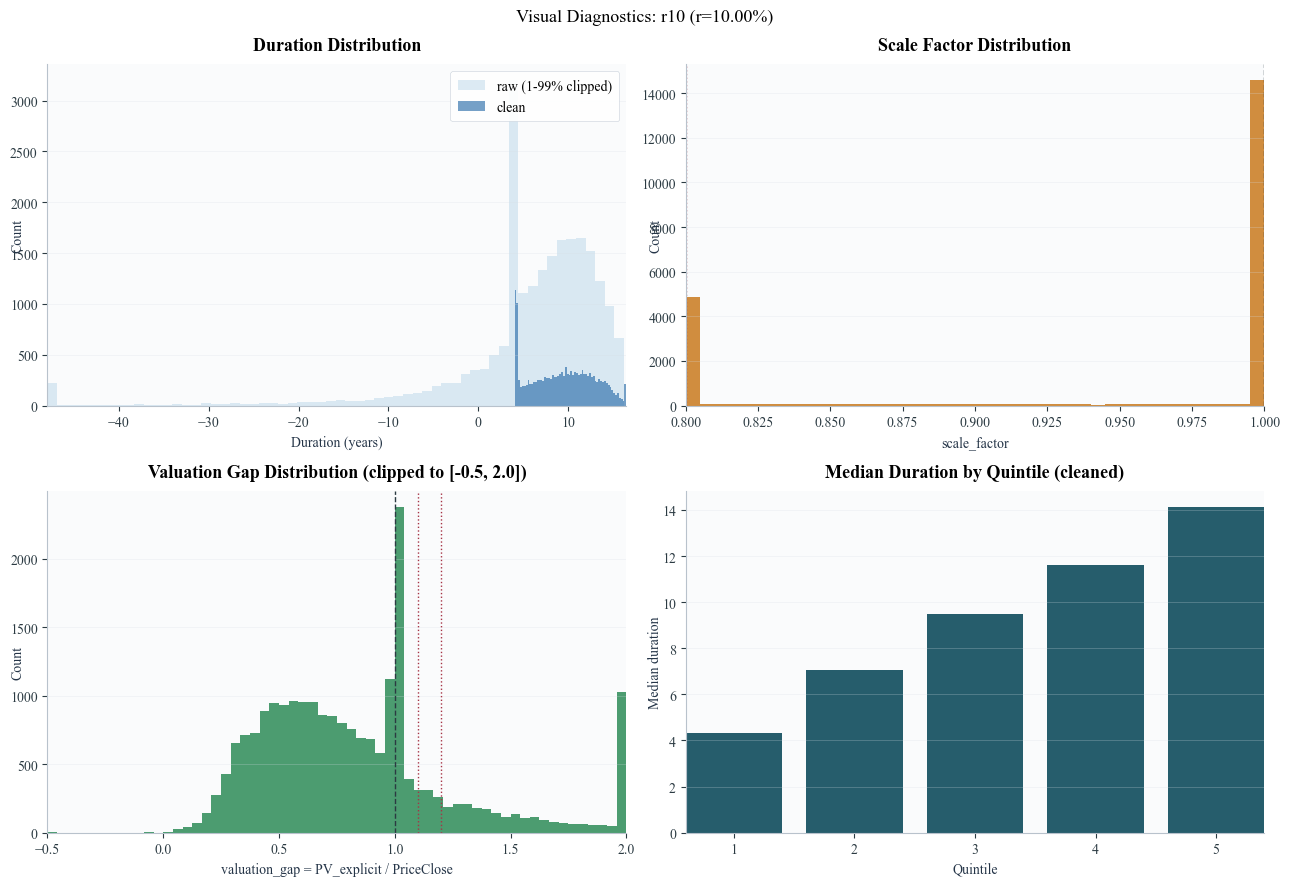

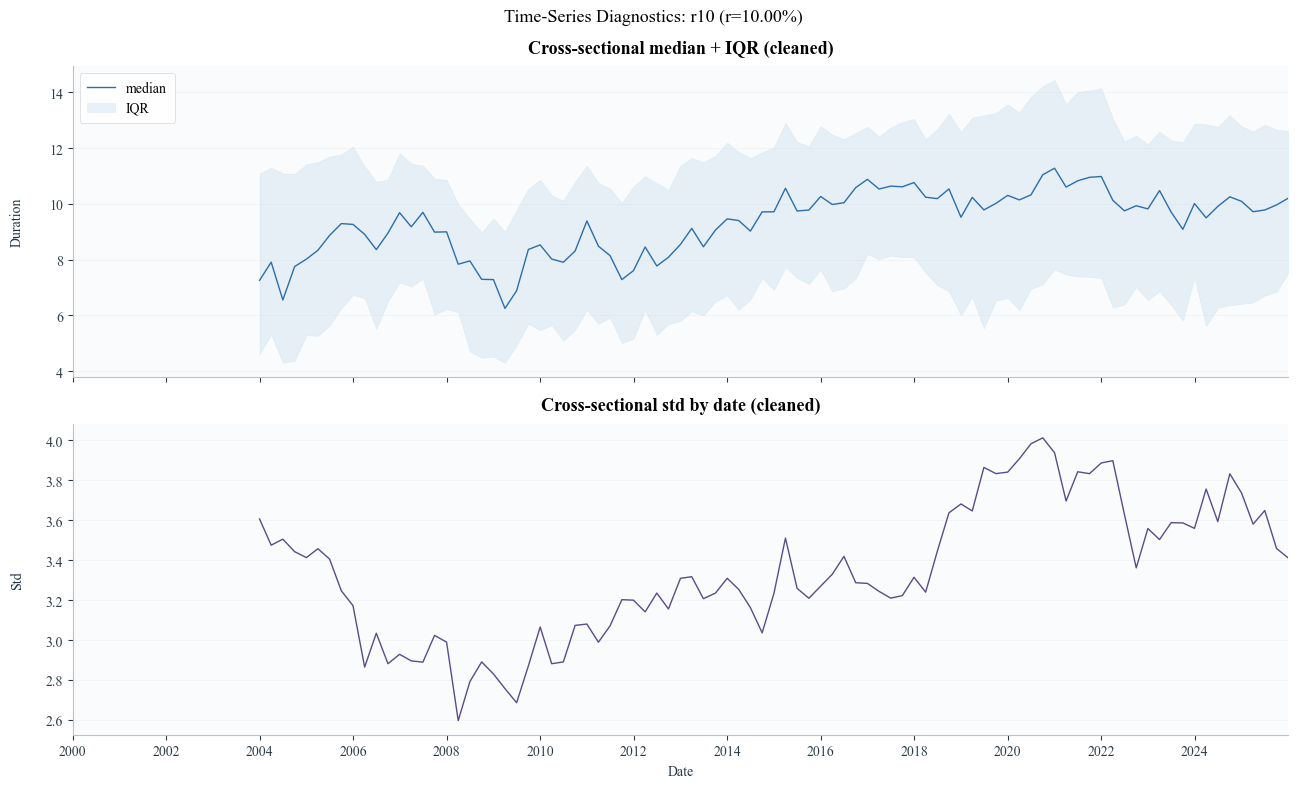

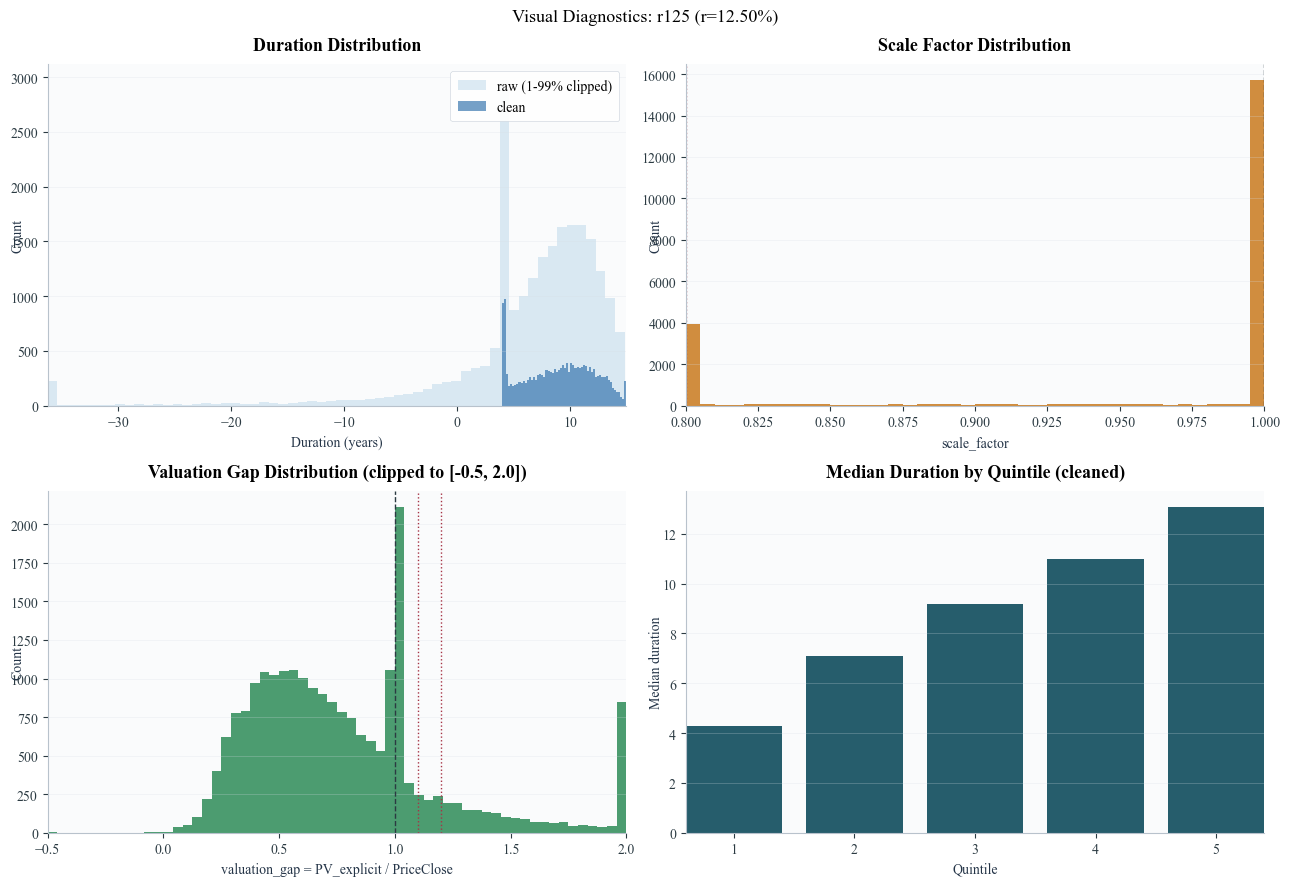

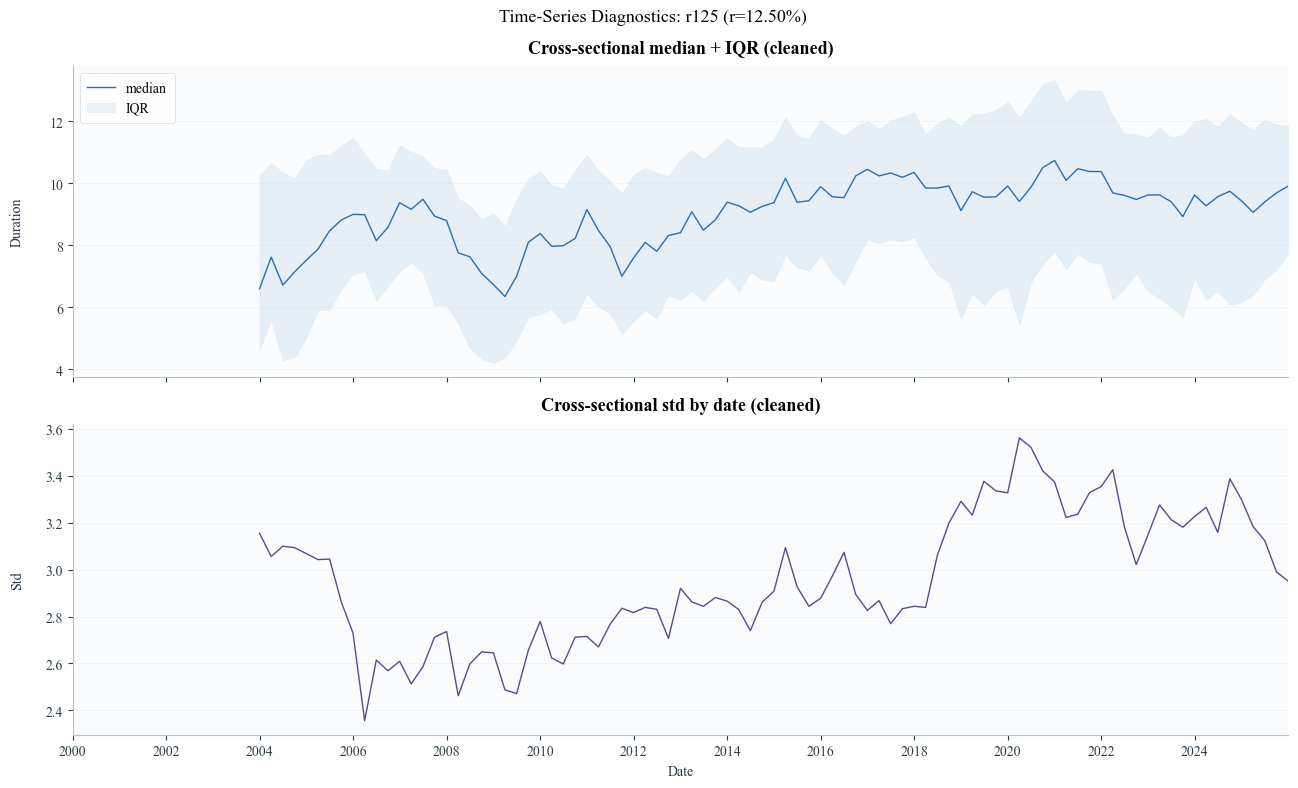

In [11]:
# Compact visual summary and stability plots
summary_rows = []
for suffix, r in RATES.items():
    clean_col = f'duration_macaulay_{suffix}_clean'
    neg_col = f'flag_negative_terminal_{suffix}'
    sf_col = f'scale_factor_{suffix}'
    vg_col = f'valuation_gap_{suffix}'

    summary_rows.append({
        'spec': suffix,
        'r': r,
        'n_obs': int(len(df)),
        'mean_duration_clean': float(df[clean_col].mean()),
        'std_duration_clean': float(df[clean_col].std()),
        'share_negative_terminal': float(df[neg_col].mean()),
        'share_retained_clean': float(df[clean_col].notna().mean()),
        'share_scaled': float((df[sf_col] < 1.0).mean()),
        'share_vgap_gt_1': float((df[vg_col] > 1.0).mean()),
        'share_vgap_gt_1_1': float((df[vg_col] > 1.1).mean()),
        'share_vgap_gt_1_2': float((df[vg_col] > 1.2).mean()),
    })

summary_df = pd.DataFrame(summary_rows)
print('Summary table (structural stability):')
print(summary_df)

for suffix, r in RATES.items():
    raw_col = f'duration_macaulay_{suffix}'
    clean_col = f'duration_macaulay_{suffix}_clean'
    sf_col = f'scale_factor_{suffix}'
    vg_col = f'valuation_gap_{suffix}'

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f'Visual Diagnostics: {suffix} (r={r:.2%})', fontsize=13)

    # 1) Duration distribution (raw vs cleaned)
    raw = df[raw_col].replace([np.inf, -np.inf], np.nan).dropna()
    clean = df[clean_col].replace([np.inf, -np.inf], np.nan).dropna()

    if len(raw) > 0:
        p_lo, p_hi = np.nanpercentile(raw, [1, 99])
        raw_clip = raw.clip(lower=p_lo, upper=p_hi)
        axes[0, 0].hist(raw_clip, bins=60, alpha=0.40, label='raw (1-99% clipped)', color=COLORS['blue_light'])
    if len(clean) > 0:
        axes[0, 0].hist(clean, bins=60, alpha=0.65, label='clean', color=COLORS['blue'])
    axes[0, 0].set_title('Duration Distribution')
    axes[0, 0].set_xlabel('Duration (years)')
    axes[0, 0].set_ylabel('Count')
    style_axes(axes[0, 0], grid_axis='y')
    style_legend(axes[0, 0], loc='upper right')

    # 2) Scale factor distribution
    sf = df[sf_col].replace([np.inf, -np.inf], np.nan).dropna()
    axes[0, 1].hist(sf, bins=40, color=COLORS['orange'], alpha=0.85)
    axes[0, 1].axvline(1.0, color=COLORS['reference'], linestyle='--', linewidth=1)
    axes[0, 1].axvline(SCALE_FLOOR, color=COLORS['red'], linestyle=':', linewidth=1)
    axes[0, 1].set_title('Scale Factor Distribution')
    axes[0, 1].set_xlabel('scale_factor')
    axes[0, 1].set_ylabel('Count')
    style_axes(axes[0, 1], grid_axis='y')

    # 3) Valuation gap distribution
    vg = df[vg_col].replace([np.inf, -np.inf], np.nan).dropna()
    vg_clip = vg.clip(lower=-0.5, upper=2.0)
    axes[1, 0].hist(vg_clip, bins=60, color=COLORS['green'], alpha=0.85)
    axes[1, 0].axvline(1.0, color=COLORS['reference'], linestyle='--', linewidth=1)
    axes[1, 0].axvline(1.1, color=COLORS['red'], linestyle=':', linewidth=1)
    axes[1, 0].axvline(1.2, color=COLORS['red'], linestyle=':', linewidth=1)
    axes[1, 0].set_title('Valuation Gap Distribution (clipped to [-0.5, 2.0])')
    axes[1, 0].set_xlabel('valuation_gap = PV_explicit / PriceClose')
    axes[1, 0].set_ylabel('Count')
    style_axes(axes[1, 0], grid_axis='y')

    # 4) Quintile medians
    valid = df[clean_col].dropna()
    if len(valid) >= 5:
        q = pd.qcut(valid, q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
        med = valid.groupby(q, observed=False).median()
        axes[1, 1].bar(med.index.astype(str), med.values, color=COLORS['primary'], alpha=0.9)
    axes[1, 1].set_title('Median Duration by Quintile (cleaned)')
    axes[1, 1].set_xlabel('Quintile')
    axes[1, 1].set_ylabel('Median duration')
    style_axes(axes[1, 1], grid_axis='y')

    plt.tight_layout()
    plt.show()

    # Time series panels (if date exists)
    if 'date' in df.columns:
        ts = df[['date', clean_col]].dropna().copy()
        ts['date'] = pd.to_datetime(ts['date'], errors='coerce')
        ts = ts.dropna(subset=['date'])

        if len(ts) > 0:
            g = ts.groupby('date')[clean_col]
            ts_stats = pd.DataFrame({
                'median': g.median(),
                'p25': g.quantile(0.25),
                'p75': g.quantile(0.75),
                'std': g.std(),
            }).dropna(how='all').sort_index()

            if len(ts_stats) > 0:
                fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
                fig.suptitle(f'Time-Series Diagnostics: {suffix} (r={r:.2%})', fontsize=13)

                ax[0].plot(ts_stats.index, ts_stats['median'], label='median', color=COLORS['blue'])
                ax[0].fill_between(ts_stats.index, ts_stats['p25'], ts_stats['p75'], alpha=0.25, color=COLORS['blue_light'], label='IQR')
                ax[0].set_ylabel('Duration')
                ax[0].set_title('Cross-sectional median + IQR (cleaned)')
                style_axes(ax[0], grid_axis='y')
                style_legend(ax[0], loc='upper left')

                ax[1].plot(ts_stats.index, ts_stats['std'], color=COLORS['purple'])
                ax[1].set_ylabel('Std')
                ax[1].set_title('Cross-sectional std by date (cleaned)')
                ax[1].set_xlabel('Date')
                style_axes(ax[1], grid_axis='y')
                style_time_axis(ax[1], x_min=ts_stats.index.min(), x_max=ts_stats.index.max(), x_ticks=ts_stats.index)

                plt.tight_layout()
                plt.show()


## 11. Coverage Analyse (Finale Duration nach Quartalen)

Coverage basiert auf `duration_macaulay_clean` (finale clean Duration der Hauptspezifikation).


Full Euro500 rows after remap: 56,500
Rows with final duration available: 16,502
Quarterly coverage table for final duration (FULL Euro500 remap):
    quarter  n_total  n_available  median_duration  p25_duration  p75_duration  coverage_share
0    1997Q4      500            0              NaN           NaN           NaN           0.000
1    1998Q1      500            0              NaN           NaN           NaN           0.000
2    1998Q2      500            0              NaN           NaN           NaN           0.000
3    1998Q3      500            0              NaN           NaN           NaN           0.000
4    1998Q4      500            0              NaN           NaN           NaN           0.000
..      ...      ...          ...              ...           ...           ...             ...
108  2024Q4      500          211        10.091244      6.411323     12.786220           0.422
109  2025Q1      500          181         9.720358      6.466103     12.600211           0.36

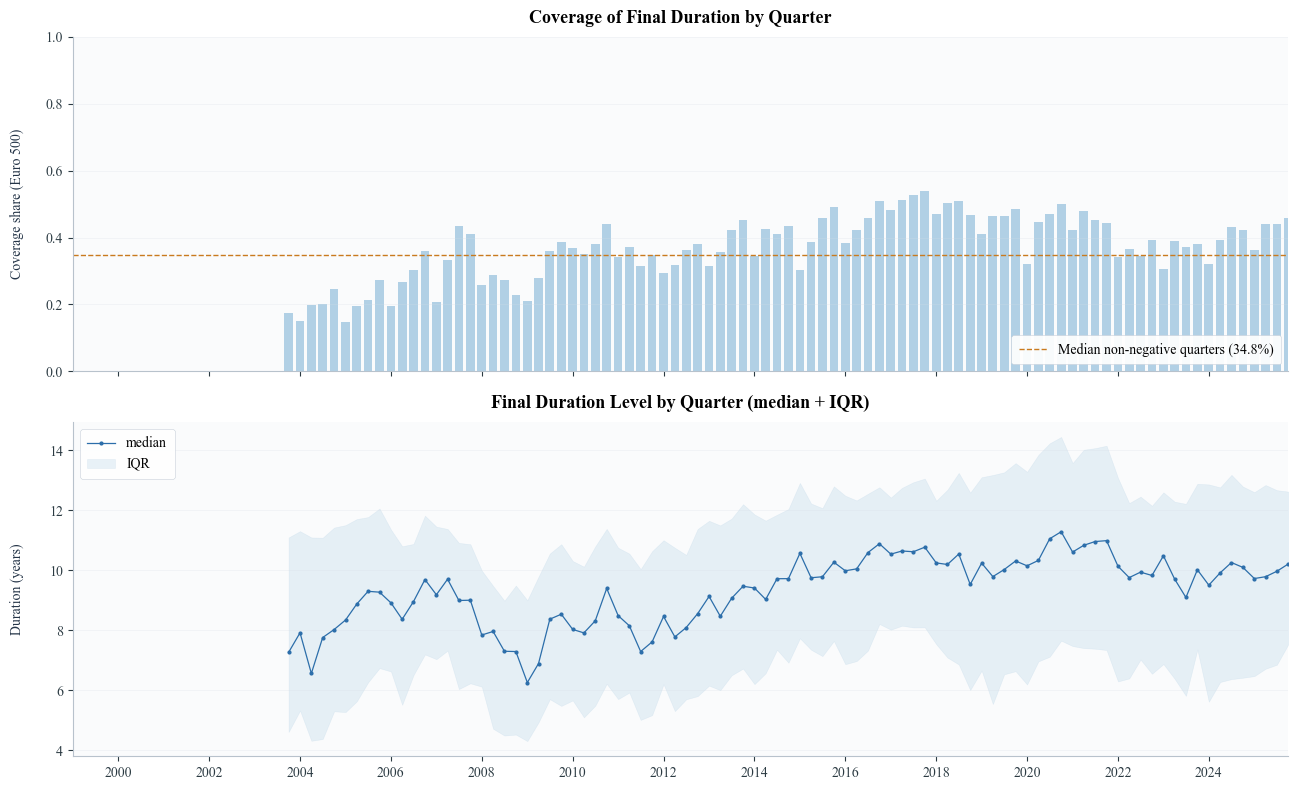

In [12]:
# Build full-Euro500 mapped output (final columns only) for steps 11 and 13
final_output_cols = [
    'duration_macaulay_r10',
    'duration_macaulay_r10_clean',
    'duration_macaulay_r125',
    'duration_macaulay_r125_clean',
    'PV_explicit_r10',
    'PV_explicit_r125',
    'PV_terminal_r10',
    'PV_terminal_r125',
    'valuation_gap_r10',
    'valuation_gap_r125',
    'scale_factor_r10',
    'scale_factor_r125',
    'flag_small_price',
    'flag_negative_terminal_r10',
    'flag_negative_terminal_r125',
    'flag_bad_duration_r10',
    'flag_bad_duration_r125',
    'flag_invalid_r10',
    'flag_invalid_r125',
    'flag_scaled_r10',
    'flag_scaled_r125',
]

missing_cols = [c for c in final_output_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required final output columns before remap: {missing_cols}')

# Keep only technical merge keys + final outputs in remapped frame
id_cols = [c for c in ['RIC', 'firm_id', 'effective_date', 'date'] if c in df_full.columns]

df_euro500_final = (
    df_full[['_row_id'] + id_cols]
    .merge(df[['_row_id'] + final_output_cols], on='_row_id', how='left')
)

print(f'Full Euro500 rows after remap: {len(df_euro500_final):,}')
print(f'Rows with final duration available: {df_euro500_final["duration_macaulay_r10_clean"].notna().sum():,}')

# Coverage analysis by quarter for final duration on FULL remapped Euro500
cov_duration_col = 'duration_macaulay_r10_clean'

if 'date' not in df_euro500_final.columns:
    print('Column `date` not found. Quarterly coverage analysis skipped.')
else:
    cov = df_euro500_final[['date', cov_duration_col]].copy()
    cov['date'] = pd.to_datetime(cov['date'], errors='coerce')
    cov = cov.dropna(subset=['date'])

    if len(cov) == 0:
        print('No valid dates for quarterly coverage analysis.')
    else:
        cov['quarter_period'] = cov['date'].dt.to_period('Q')

        q_cov = (
            cov.groupby('quarter_period', dropna=False)
            .agg(
                n_total=(cov_duration_col, 'size'),
                n_available=(cov_duration_col, lambda s: s.notna().sum()),
                median_duration=(cov_duration_col, 'median'),
                p25_duration=(cov_duration_col, lambda s: s.quantile(0.25)),
                p75_duration=(cov_duration_col, lambda s: s.quantile(0.75)),
            )
            .reset_index()
            .sort_values('quarter_period')
        )

        q_cov['quarter'] = q_cov['quarter_period'].astype(str)
        q_cov['quarter_ts'] = q_cov['quarter_period'].dt.to_timestamp()
        q_cov['coverage_share'] = q_cov['n_available'] / q_cov['n_total']

        print('Quarterly coverage table for final duration (FULL Euro500 remap):')
        print(q_cov[['quarter', 'n_total', 'n_available', 'median_duration', 'p25_duration', 'p75_duration', 'coverage_share']])

        fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

        ax[0].bar(q_cov['quarter_ts'], q_cov['coverage_share'], width=70, color=COLORS['blue_light'], alpha=0.9)
        ref_mask = q_cov['coverage_share'].ge(0) & q_cov['coverage_share'].notna()
        ref_median = q_cov.loc[ref_mask, 'coverage_share'].median()
        if pd.notna(ref_median):
            ax[0].axhline(ref_median, color=COLORS['orange'], linestyle='--', linewidth=1, label=f"Median non-negative quarters ({ref_median:.1%})")
        ax[0].set_ylim(0, 1.0)
        ax[0].set_ylabel('Coverage share (Euro 500)')
        ax[0].set_title('Coverage of Final Duration by Quarter')
        style_axes(ax[0], grid_axis='y')
        style_legend(ax[0], loc='lower right')

        ax[1].plot(q_cov['quarter_ts'], q_cov['median_duration'], color=COLORS['blue'], linewidth=0.9, marker='o', markersize=2.0, label='median')
        ax[1].fill_between(q_cov['quarter_ts'], q_cov['p25_duration'], q_cov['p75_duration'], color=COLORS['blue_light'], alpha=0.25, label='IQR')
        ax[1].set_ylabel('Duration (years)')
        ax[1].set_title('Final Duration Level by Quarter (median + IQR)')
        style_axes(ax[1], grid_axis='y')
        style_legend(ax[1], loc='upper left')

        # Enforce shared project time-axis rules: start at 1999, labels from 2000 every 2 years.
        style_time_axis(
            ax[1],
            x_min=pd.Timestamp('1999-01-01'),
            x_max=q_cov['quarter_ts'].max(),
            x_ticks=q_cov['quarter_ts'],
            date_fmt='%Y',
        )

        plt.tight_layout()
        STEP11_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(STEP11_FIG_PATH, dpi=300, bbox_inches='tight')
        print(f'Saved Step 11 figure: {STEP11_FIG_PATH.resolve()}')
        plt.show()


## 12. Output


In [13]:
# Save remapped full-Euro500 output with only merge keys + final output columns
if 'df_euro500_final' not in globals():
    raise ValueError('df_euro500_final not found. Run Step 11 before Step 13 output save.')

save_cols = [c for c in ['RIC', 'firm_id', 'effective_date', 'date'] if c in df_euro500_final.columns] + final_output_cols

df_to_save = df_euro500_final[save_cols].copy()

df_to_save.to_parquet(OUTPUT_PATH, index=False)

print(f'Saved (intermediate): {OUTPUT_PATH.resolve()}')
print(f'Rows saved (FULL Euro500): {len(df_to_save):,}')
print('Saved only merge keys plus final output columns.')


Saved (intermediate): /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Macaulay.parquet
Rows saved (FULL Euro500): 56,500
Saved only merge keys plus final output columns.


## 13. Economic Validation

### "Cross-Sectional Economic Validation"

Book-to-market is a key benchmark because duration-like equities should look more growth-like (low B/M) and less value-like (high B/M).

Expected signs for a meaningful equity-duration proxy:
- corr(duration, bm) < 0
- corr(duration, ep) < 0
- corr(duration, growth) > 0

The checks below use cross-sectional correlations, duration-sorted and bm-sorted portfolios, and a compact multivariate regression.


In [14]:
# Step 14 — Cross-sectional economic validation (non-invasive, add-on diagnostics)

# --- helpers ---------------------------------------------------------------
def _first_existing(frame: pd.DataFrame, candidates, required: bool = False, label: str = ""):
    for c in candidates:
        if c in frame.columns:
            return c
    if required:
        raise KeyError(f"No candidate column found for {label or 'requested field'}: {candidates}")
    return None


def _to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')


def _winsor_series(s: pd.Series, lo: float = 0.01, hi: float = 0.99) -> pd.Series:
    s = _to_num(s).replace([np.inf, -np.inf], np.nan)
    valid = s.dropna()
    if valid.empty:
        return s
    ql, qh = valid.quantile([lo, hi])
    return s.clip(lower=ql, upper=qh)


def _corr_row(frame: pd.DataFrame, x: str, y: str) -> dict:
    tmp = frame[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) == 0:
        return {'variable': y, 'n_obs': 0, 'pearson': np.nan, 'spearman': np.nan}
    return {
        'variable': y,
        'n_obs': int(len(tmp)),
        'pearson': float(tmp[x].corr(tmp[y], method='pearson')),
        'spearman': float(tmp[x].corr(tmp[y], method='spearman')),
    }


def _build_ols_table(frame: pd.DataFrame, y_col: str, x_cols: list, date_col=None, max_date_fe: int = 80):
    req = [y_col] + x_cols
    reg = frame[req + ([date_col] if date_col else [])].replace([np.inf, -np.inf], np.nan).dropna(subset=req).copy()
    if reg.empty:
        return pd.DataFrame(columns=['term', 'coef', 't_stat', 'n_obs', 'r2'])

    X_parts = [pd.Series(1.0, index=reg.index, name='const')]
    X_parts += [reg[c].astype(float).rename(c) for c in x_cols]

    use_date_fe = False
    if date_col and date_col in reg.columns:
        n_dates = reg[date_col].nunique(dropna=True)
        use_date_fe = n_dates > 1 and n_dates <= max_date_fe
        if use_date_fe:
            dummies = pd.get_dummies(reg[date_col], prefix='date_fe', drop_first=True, dtype=float)
            if dummies.shape[1] > 0:
                X_parts.append(dummies)

    X = pd.concat(X_parts, axis=1).astype(float)
    y = reg[y_col].astype(float)

    X_mat = X.to_numpy(dtype=float)
    y_vec = y.to_numpy(dtype=float)
    n, k = X_mat.shape
    if n <= k:
        return pd.DataFrame(columns=['term', 'coef', 't_stat', 'n_obs', 'r2'])

    xtx = X_mat.T @ X_mat
    try:
        xtx_inv = np.linalg.inv(xtx)
    except np.linalg.LinAlgError:
        xtx_inv = np.linalg.pinv(xtx)

    beta = xtx_inv @ (X_mat.T @ y_vec)
    y_hat = X_mat @ beta
    resid = y_vec - y_hat

    sse = float(np.sum(resid ** 2))
    sst = float(np.sum((y_vec - y_vec.mean()) ** 2))
    r2 = np.nan if sst <= 0 else (1.0 - sse / sst)

    dof = max(n - k, 1)
    sigma2 = sse / dof
    var_beta = sigma2 * xtx_inv
    se_beta = np.sqrt(np.clip(np.diag(var_beta), a_min=0, a_max=None))
    t_stats = np.divide(beta, se_beta, out=np.full_like(beta, np.nan), where=se_beta > 0)

    out = pd.DataFrame({
        'term': X.columns,
        'coef': beta,
        't_stat': t_stats,
    })
    out['n_obs'] = int(n)
    out['r2'] = r2

    keep_terms = ['const'] + x_cols
    out = out[out['term'].isin(keep_terms)].copy().reset_index(drop=True)
    out['spec'] = 'pooled_ols_with_date_fe' if use_date_fe else 'pooled_ols'
    return out[['spec', 'term', 'coef', 't_stat', 'n_obs', 'r2']]


# --- variable construction -------------------------------------------------
val = df.copy()

duration_col = _first_existing(
    val,
    ['duration_macaulay_clean', 'duration_macaulay_r10_clean', 'duration_macaulay'],
    required=True,
    label='duration_macaulay_clean'
)

price_col = _first_existing(val, ['PriceClose', 'price_close'], required=True, label='price')
mcap_col = _first_existing(val, ['mcap_eur', 'MarketCap', 'market_cap', 'marketcap'])
shares_col = _first_existing(val, ['shares_outstanding', 'SharesOutstanding', 'shares'])
be_col = _first_existing(val, ['BE', 'book_equity', 'BookEquity', 'book_value', 'BookValue'])
ltg_col = _first_existing(val, ['LTG_decimal', 'LTG'])

if mcap_col is None and shares_col is not None:
    val['mcap_implied'] = _to_num(val[shares_col]) * _to_num(val[price_col])
    mcap_col = 'mcap_implied'

# bm: MUST come from EQDuration_Netpayout.parquet (mapped into current df)
netpayout_candidates = [
    Path('EQDuration_Netpayout.parquet'),
    Path('EQDuration_NetPayout.parquet'),
    Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Netpayout.parquet'),
    Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_NetPayout.parquet'),
]
NETPAYOUT_PATH = next((x for x in netpayout_candidates if x.exists()), None)
if NETPAYOUT_PATH is None:
    raise FileNotFoundError('BM mapping source not found: EQDuration_Netpayout.parquet')

np_src = pd.read_parquet(NETPAYOUT_PATH).copy()
bm_src_col = _first_existing(np_src, ['bm', 'BM', 'book_to_market', 'book_market', 'B2M'], required=True, label='netpayout bm')

merge_done = False
if ('firm_id' in val.columns) and ('firm_id' in np_src.columns) and ('date' in val.columns) and ('date' in np_src.columns):
    val['firm_id'] = val['firm_id'].astype(str).str.strip()
    np_src['firm_id'] = np_src['firm_id'].astype(str).str.strip()
    val['date'] = pd.to_datetime(val['date'], errors='coerce').dt.normalize()
    np_src['date'] = pd.to_datetime(np_src['date'], errors='coerce').dt.normalize()
    np_map = np_src[['firm_id', 'date', bm_src_col]].drop_duplicates(['firm_id', 'date'], keep='last').copy()
    val = val.merge(np_map.rename(columns={bm_src_col: 'bm_from_netpayout'}), on=['firm_id', 'date'], how='left')
    merge_done = True
elif ('firm_id' in val.columns) and ('firm_id' in np_src.columns) and ('effective_date' in val.columns) and ('effective_date' in np_src.columns):
    val['firm_id'] = val['firm_id'].astype(str).str.strip()
    np_src['firm_id'] = np_src['firm_id'].astype(str).str.strip()
    val['effective_date'] = pd.to_datetime(val['effective_date'], errors='coerce').dt.normalize()
    np_src['effective_date'] = pd.to_datetime(np_src['effective_date'], errors='coerce').dt.normalize()
    np_map = np_src[['firm_id', 'effective_date', bm_src_col]].drop_duplicates(['firm_id', 'effective_date'], keep='last').copy()
    val = val.merge(np_map.rename(columns={bm_src_col: 'bm_from_netpayout'}), on=['firm_id', 'effective_date'], how='left')
    merge_done = True
elif ('RIC' in val.columns) and ('RIC' in np_src.columns) and ('date' in val.columns) and ('date' in np_src.columns):
    val['RIC'] = val['RIC'].astype(str).str.strip()
    np_src['RIC'] = np_src['RIC'].astype(str).str.strip()
    val['date'] = pd.to_datetime(val['date'], errors='coerce').dt.normalize()
    np_src['date'] = pd.to_datetime(np_src['date'], errors='coerce').dt.normalize()
    np_map = np_src[['RIC', 'date', bm_src_col]].drop_duplicates(['RIC', 'date'], keep='last').copy()
    val = val.merge(np_map.rename(columns={bm_src_col: 'bm_from_netpayout'}), on=['RIC', 'date'], how='left')
    merge_done = True

if not merge_done:
    raise KeyError('Could not map bm from EQDuration_Netpayout.parquet: no common merge keys found.')

val['bm'] = _to_num(val['bm_from_netpayout'])
if val['bm'].notna().sum() == 0:
    raise ValueError('bm mapping from EQDuration_Netpayout.parquet returned zero non-null matches.')

print(f'BM mapped from {NETPAYOUT_PATH} | non-null matches: {int(val["bm"].notna().sum()):,}')

# ep: earnings-to-price proxy with cash EPS preferred
eps_proxy_col = _first_existing(val, ['EPS_CashAct', 'EPS_FY1', 'C1'])
if eps_proxy_col is not None:
    price_num = _to_num(val[price_col])
    eps_num = _to_num(val[eps_proxy_col])
    val['ep'] = np.where(price_num > 0, eps_num / price_num, np.nan)
else:
    val['ep'] = np.nan

# size: log market cap
if mcap_col is not None:
    mc = _to_num(val[mcap_col])
    val['size'] = np.where(mc > 0, np.log(mc), np.nan)
else:
    val['size'] = np.nan

# growth: LTG decimal if already available, else LTG/100
if ltg_col is not None:
    ltg_raw = _to_num(val[ltg_col])
    if ltg_col == 'LTG':
        ltg_raw = ltg_raw / 100.0
    val['growth'] = ltg_raw
else:
    val['growth'] = np.nan

# optional profitability proxy
profit_col = _first_existing(val, ['net_income', 'NetIncome'])
if profit_col is not None and be_col is not None:
    be_num = _to_num(val[be_col])
    ni_num = _to_num(val[profit_col])
    val['profitability'] = np.where(be_num > 0, ni_num / be_num, np.nan)

# clean + winsor (for diagnostics only)
val['duration_macaulay_clean_for_val'] = _winsor_series(val[duration_col], 0.01, 0.99)
for c in ['bm', 'ep', 'size', 'growth', 'profitability']:
    if c in val.columns:
        val[c] = _to_num(val[c]).replace([np.inf, -np.inf], np.nan)
        val[f'{c}_w'] = _winsor_series(val[c], 0.01, 0.99)

# --- Table A: correlations -------------------------------------------------
corr_vars = ['bm_w', 'ep_w', 'size_w', 'growth_w']
rows_a = [_corr_row(val, 'duration_macaulay_clean_for_val', v) for v in corr_vars]
table_a = pd.DataFrame(rows_a)
name_map = {'bm_w': 'bm', 'ep_w': 'ep', 'size_w': 'size', 'growth_w': 'growth'}
table_a['variable'] = table_a['variable'].map(name_map).fillna(table_a['variable'])

display(table_a)

# --- Table B: duration quintiles ------------------------------------------
q_src = val[['duration_macaulay_clean_for_val', 'bm_w', 'growth_w', 'size_w']].copy()
q_src = q_src.dropna(subset=['duration_macaulay_clean_for_val'])

if len(q_src) >= 5:
    q_src['duration_quintile'] = pd.qcut(
        q_src['duration_macaulay_clean_for_val'],
        q=5,
        labels=[1, 2, 3, 4, 5],
        duplicates='drop'
    ).astype(float)

    table_b = (
        q_src.groupby('duration_quintile', dropna=False)
        .agg(
            median_duration=('duration_macaulay_clean_for_val', 'median'),
            mean_bm=('bm_w', 'mean'),
            median_bm=('bm_w', 'median'),
            mean_growth=('growth_w', 'mean'),
            mean_size=('size_w', 'mean'),
            n=('duration_macaulay_clean_for_val', 'size'),
        )
        .reset_index()
        .sort_values('duration_quintile')
    )
else:
    table_b = pd.DataFrame(columns=['duration_quintile', 'median_duration', 'mean_bm', 'median_bm', 'mean_growth', 'mean_size', 'n'])

display(table_b)

# --- Ranking check: bm quintiles -> duration -------------------------------
bm_rank = val[['bm_w', 'duration_macaulay_clean_for_val']].dropna().copy()
if len(bm_rank) >= 5:
    bm_rank['bm_quintile'] = pd.qcut(bm_rank['bm_w'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(float)
    bm_rank_check = (
        bm_rank.groupby('bm_quintile', dropna=False)
        .agg(
            mean_duration=('duration_macaulay_clean_for_val', 'mean'),
            median_duration=('duration_macaulay_clean_for_val', 'median'),
            n=('duration_macaulay_clean_for_val', 'size'),
        )
        .reset_index()
        .sort_values('bm_quintile')
    )
else:
    bm_rank_check = pd.DataFrame(columns=['bm_quintile', 'mean_duration', 'median_duration', 'n'])

print('Ranking check (bm quintiles -> duration):')
display(bm_rank_check)

# keep for next cells
validation_df = val.copy()
validation_table_a = table_a.copy()
validation_table_b = table_b.copy()
validation_bm_rank_check = bm_rank_check.copy()





BM mapped from /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Netpayout.parquet | non-null matches: 21,095


,variable,n_obs,pearson,spearman
0,bm,15918,-0.476342,-0.474522
1,ep,14673,-0.681842,-0.800483
2,size,16502,0.113989,0.105447
3,growth,13238,0.038137,0.083874


,duration_quintile,median_duration,mean_bm,median_bm,mean_growth,mean_size,n
0,1.0,4.333481,-0.418490,-0.430145,0.109359,22.539242,3301
1,2.0,7.057464,-0.585658,-0.600934,0.106973,22.527736,3300
2,3.0,9.481225,-0.765280,-0.809278,0.106772,22.580078,3300
3,4.0,11.624140,-1.023274,-1.039110,0.107355,22.655745,3300
4,5.0,14.111430,-1.340275,-1.423970,0.121484,22.967643,3301


Ranking check (bm quintiles -> duration):


,bm_quintile,mean_duration,median_duration,n
0,1.0,12.288749,12.825405,3184
1,2.0,10.139821,10.478726,3183
2,3.0,8.792723,8.980338,3185
3,4.0,7.832768,7.601198,3184
4,5.0,7.786391,7.038475,3182


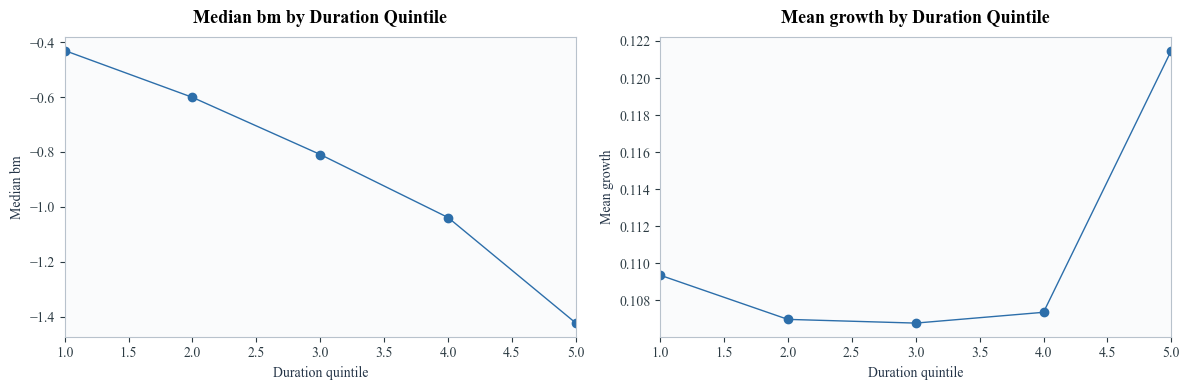

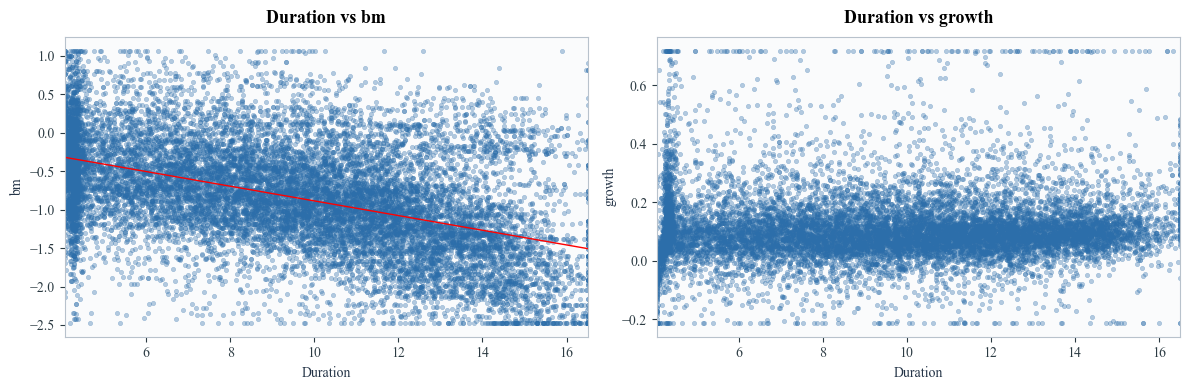

In [15]:
# Step 14 plots (matplotlib only, no seaborn)
if 'validation_df' not in globals() or 'validation_table_b' not in globals():
    raise RuntimeError('Run validation variable/table cell first.')

plot_df = validation_df.copy()

# 1) line: duration quintile vs median bm
if not validation_table_b.empty:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(validation_table_b['duration_quintile'], validation_table_b['median_bm'], marker='o')
    ax[0].set_xlabel('Duration quintile')
    ax[0].set_ylabel('Median bm')
    ax[0].set_title('Median bm by Duration Quintile')

    # 2) line: duration quintile vs mean growth
    ax[1].plot(validation_table_b['duration_quintile'], validation_table_b['mean_growth'], marker='o')
    ax[1].set_xlabel('Duration quintile')
    ax[1].set_ylabel('Mean growth')
    ax[1].set_title('Mean growth by Duration Quintile')

    plt.tight_layout()
    plt.show()

# 3) scatter duration vs bm + linear fit
sc1 = plot_df[['duration_macaulay_clean_for_val', 'bm_w']].dropna().copy()
sc2 = plot_df[['duration_macaulay_clean_for_val', 'growth_w']].dropna().copy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(sc1['duration_macaulay_clean_for_val'], sc1['bm_w'], s=10, alpha=0.35)
if len(sc1) >= 2:
    x = sc1['duration_macaulay_clean_for_val'].to_numpy(dtype=float)
    y = sc1['bm_w'].to_numpy(dtype=float)
    b1, b0 = np.polyfit(x, y, 1)
    xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax[0].plot(xx, b1 * xx + b0, color='red', linewidth=1)
ax[0].set_xlabel('Duration')
ax[0].set_ylabel('bm')
ax[0].set_title('Duration vs bm')

# 4) scatter duration vs growth
ax[1].scatter(sc2['duration_macaulay_clean_for_val'], sc2['growth_w'], s=10, alpha=0.35)
ax[1].set_xlabel('Duration')
ax[1].set_ylabel('growth')
ax[1].set_title('Duration vs growth')

plt.tight_layout()
plt.show()



In [16]:
# Step 14 regression, flags, targeted small adjustments, and exports
if 'validation_df' not in globals():
    raise RuntimeError('Run validation setup cell first.')

val = validation_df.copy()

# --- Table C: compact cross-sectional regression --------------------------
reg_date_col = 'date' if 'date' in val.columns else None
table_c = _build_ols_table(
    frame=val,
    y_col='duration_macaulay_clean_for_val',
    x_cols=['bm_w', 'size_w', 'growth_w'],
    date_col=reg_date_col,
)

pretty_terms = {'const': 'a', 'bm_w': 'bm', 'size_w': 'size', 'growth_w': 'growth'}
if not table_c.empty:
    table_c['term'] = table_c['term'].map(pretty_terms).fillna(table_c['term'])

display(table_c)

# --- flags ----------------------------------------------------------------
base = val.copy()

# extreme bm: negative or very high
bm_hi = base['bm_w'].quantile(0.99) if base['bm_w'].notna().any() else np.nan
base['flag_extreme_bm'] = (base['bm_w'] < 0) | (base['bm_w'] > bm_hi)

# extreme duration via tails
d_lo = base['duration_macaulay_clean_for_val'].quantile(0.01) if base['duration_macaulay_clean_for_val'].notna().any() else np.nan
d_hi = base['duration_macaulay_clean_for_val'].quantile(0.99) if base['duration_macaulay_clean_for_val'].notna().any() else np.nan
base['flag_extreme_duration'] = (base['duration_macaulay_clean_for_val'] < d_lo) | (base['duration_macaulay_clean_for_val'] > d_hi)

# extreme scale_factor (prefer raw if available)
sf_col = _first_existing(base, ['sf_raw_r10', 'scale_factor_r10', 'scale_factor'])
if sf_col is not None:
    sf = _to_num(base[sf_col])
    sf_hi = sf.quantile(0.99) if sf.notna().any() else np.nan
    base['flag_extreme_scale_factor'] = (sf < 0.5) | (sf > sf_hi)
else:
    base['flag_extreme_scale_factor'] = False

# invalid price ratios (price <= 0 or ep invalid)
price_col = _first_existing(base, ['PriceClose', 'price_close'])
price_num = _to_num(base[price_col])
base['flag_invalid_price_ratio'] = (price_num <= 0) | (~np.isfinite(base['ep_w']))

base['flag_bad_obs_any'] = (
    base['flag_extreme_bm'].fillna(False)
    | base['flag_extreme_duration'].fillna(False)
    | base['flag_extreme_scale_factor'].fillna(False)
    | base['flag_invalid_price_ratio'].fillna(False)
)

# correlation full vs filtered
full_pair = base[['duration_macaulay_clean_for_val', 'bm_w']].dropna().copy()
flt_pair = base.loc[~base['flag_bad_obs_any'], ['duration_macaulay_clean_for_val', 'bm_w']].dropna().copy()

corr_full = full_pair['duration_macaulay_clean_for_val'].corr(full_pair['bm_w']) if len(full_pair) else np.nan
corr_filtered = flt_pair['duration_macaulay_clean_for_val'].corr(flt_pair['bm_w']) if len(flt_pair) else np.nan

# --- small targeted fixes (only if needed) -------------------------------
weak_or_wrong = pd.isna(corr_full) or (corr_full >= 0) or (abs(corr_full) < 0.03)

adj = base.copy()
adj_applied = []

if weak_or_wrong:
    # 1) tighter LTG cap
    adj['growth_tight'] = adj['growth_w'].clip(lower=-0.02, upper=0.06)
    adj_applied.append('growth clip to [-0.02, 0.06]')

    # 2) remove extreme raw scale_factor < 0.5 when available
    if sf_col is not None:
        adj = adj[~(_to_num(adj[sf_col]) < 0.5)].copy()
        adj_applied.append('drop scale_factor < 0.5')

    # 3) winsorize duration at 1/99
    adj['duration_adj'] = _winsor_series(adj['duration_macaulay_clean_for_val'], 0.01, 0.99)
    adj_applied.append('winsorize duration at 1%/99%')
else:
    adj['growth_tight'] = adj['growth_w']
    adj['duration_adj'] = adj['duration_macaulay_clean_for_val']
    adj_applied.append('no additional adjustment needed')

adj_pair = adj[['duration_adj', 'bm_w']].dropna().copy()
corr_adjusted = adj_pair['duration_adj'].corr(adj_pair['bm_w']) if len(adj_pair) else np.nan

# Table D: full vs filtered vs adjusted

def _dist_stats(s: pd.Series) -> dict:
    s = _to_num(s).replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return {'mean_duration': np.nan, 'std_duration': np.nan, 'p10_duration': np.nan, 'p50_duration': np.nan, 'p90_duration': np.nan}
    q = s.quantile([0.10, 0.50, 0.90])
    return {
        'mean_duration': float(s.mean()),
        'std_duration': float(s.std()),
        'p10_duration': float(q.loc[0.10]),
        'p50_duration': float(q.loc[0.50]),
        'p90_duration': float(q.loc[0.90]),
    }

full_stats = _dist_stats(base['duration_macaulay_clean_for_val'])
flt_stats = _dist_stats(base.loc[~base['flag_bad_obs_any'], 'duration_macaulay_clean_for_val'])
adj_stats = _dist_stats(adj['duration_adj'])

table_d = pd.DataFrame([
    {'sample': 'full', 'n_obs': int(len(full_pair)), 'corr_duration_bm': corr_full, **full_stats},
    {'sample': 'filtered_flags', 'n_obs': int(len(flt_pair)), 'corr_duration_bm': corr_filtered, **flt_stats},
    {'sample': 'adjusted_if_needed', 'n_obs': int(len(adj_pair)), 'corr_duration_bm': corr_adjusted, **adj_stats},
])

display(table_d)
print('Small adjustments status:', '; '.join(adj_applied))

# --- exports: Tables A-D + final validation dataset -----------------------
out_dir = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/duration tables')
out_dir.mkdir(parents=True, exist_ok=True)

table_a_path = out_dir / 'EQDuration_Macaulay_TableA_Correlations.csv'
table_b_path = out_dir / 'EQDuration_Macaulay_TableB_Quintiles.csv'
table_c_path = out_dir / 'EQDuration_Macaulay_TableC_Regression.csv'
table_d_path = out_dir / 'EQDuration_Macaulay_TableD_Full_vs_Filtered.csv'

validation_table_a.to_csv(table_a_path, index=False)
validation_table_b.to_csv(table_b_path, index=False)
table_c.to_csv(table_c_path, index=False)
table_d.to_csv(table_d_path, index=False)

# final dataset with requested columns + flags
final_cols = [
    c for c in [
        'RIC', 'firm_id', 'effective_date', 'date',
        'duration_macaulay_clean_for_val', 'bm_w', 'growth_w', 'size_w',
        'flag_extreme_bm', 'flag_extreme_duration', 'flag_extreme_scale_factor',
        'flag_invalid_price_ratio', 'flag_bad_obs_any'
    ] if c in base.columns
]

final_validation_dataset = base[final_cols].rename(columns={
    'duration_macaulay_clean_for_val': 'duration_macaulay',
    'bm_w': 'bm',
    'growth_w': 'growth',
    'size_w': 'size',
}).copy()

final_dataset_parquet = out_dir / 'EQDuration_Macaulay_validation.parquet'
final_dataset_csv = out_dir / 'EQDuration_Macaulay_validation.csv'

final_validation_dataset.to_parquet(final_dataset_parquet, index=False)
final_validation_dataset.to_csv(final_dataset_csv, index=False)

print('Saved Table A:', table_a_path.resolve())
print('Saved Table B:', table_b_path.resolve())
print('Saved Table C:', table_c_path.resolve())
print('Saved Table D:', table_d_path.resolve())
print('Saved validation dataset (parquet):', final_dataset_parquet.resolve())
print('Saved validation dataset (csv):', final_dataset_csv.resolve())

# expose for downstream notebook usage
validation_table_c = table_c.copy()
validation_table_d = table_d.copy()
validation_with_flags = base.copy()
validation_adjusted = adj.copy()




,spec,term,coef,t_stat,n_obs,r2
0,pooled_ols,a,1.779867,3.760263,12804,0.253896
1,pooled_ols,bm,-2.469039,-63.484059,12804,0.253896
2,pooled_ols,size,0.242087,11.667170,12804,0.253896
3,pooled_ols,growth,-0.228486,-1.038765,12804,0.253896


,sample,n_obs,corr_duration_bm,mean_duration,std_duration,p10_duration,p50_duration,p90_duration
0,full,15918,-0.476342,9.379852,3.481822,4.333483,9.481225,14.111274
1,filtered_flags,1516,-0.138542,7.971013,3.352407,4.246349,7.316334,13.177790
2,adjusted_if_needed,15918,-0.476342,9.379852,3.481822,4.333483,9.481225,14.111274


Small adjustments status: no additional adjustment needed
Saved Table A: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/duration tables/EQDuration_Macaulay_TableA_Correlations.csv
Saved Table B: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/duration tables/EQDuration_Macaulay_TableB_Quintiles.csv
Saved Table C: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/duration tables/EQDuration_Macaulay_TableC_Regression.csv
Saved Table D: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/duration tables/EQDuration_Macaulay_TableD_Full_vs_Filtered.csv
Saved validation dataset (parquet): /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/duration tables/EQDuration_Macaulay_validation.parquet
Saved validation dataset (csv): /Users/jakob/Documents/Parforceleistung/Studi

## 14. Scaling and Growth Diagnostics

### "Scaling and Growth Diagnostics"

This section adds targeted diagnostics to assess whether scaling compresses growth firms and whether alternative duration constructions improve economic sensitivity, while keeping the existing Macaulay setup unchanged.


In [17]:
# Step 15A — growth proxies + scaling diagnostics + extended validation + joint regression

val2 = df.copy()

# Helpers (fallback if Section 14 helpers are not in memory)
if '_first_existing' not in globals():
    def _first_existing(frame: pd.DataFrame, candidates, required: bool = False, label: str = ''):
        for c in candidates:
            if c in frame.columns:
                return c
        if required:
            raise KeyError(f"No candidate column found for {label or 'requested field'}: {candidates}")
        return None

if '_to_num' not in globals():
    def _to_num(s: pd.Series) -> pd.Series:
        return pd.to_numeric(s, errors='coerce')

if '_winsor_series' not in globals():
    def _winsor_series(s: pd.Series, lo: float = 0.01, hi: float = 0.99) -> pd.Series:
        s = _to_num(s).replace([np.inf, -np.inf], np.nan)
        v = s.dropna()
        if v.empty:
            return s
        ql, qh = v.quantile([lo, hi])
        return s.clip(lower=ql, upper=qh)

if '_build_ols_table' not in globals():
    def _build_ols_table(frame: pd.DataFrame, y_col: str, x_cols: list, date_col=None, max_date_fe: int = 80):
        req = [y_col] + x_cols
        reg = frame[req + ([date_col] if date_col else [])].replace([np.inf, -np.inf], np.nan).dropna(subset=req).copy()
        if reg.empty:
            return pd.DataFrame(columns=['spec', 'term', 'coef', 't_stat', 'n_obs', 'r2'])

        X_parts = [pd.Series(1.0, index=reg.index, name='const')]
        X_parts += [reg[c].astype(float).rename(c) for c in x_cols]

        use_date_fe = False
        if date_col and date_col in reg.columns:
            n_dates = reg[date_col].nunique(dropna=True)
            use_date_fe = n_dates > 1 and n_dates <= max_date_fe
            if use_date_fe:
                dummies = pd.get_dummies(reg[date_col], prefix='date_fe', drop_first=True, dtype=float)
                if dummies.shape[1] > 0:
                    X_parts.append(dummies)

        X = pd.concat(X_parts, axis=1).astype(float)
        y = reg[y_col].astype(float)

        X_mat = X.to_numpy(dtype=float)
        y_vec = y.to_numpy(dtype=float)
        n, k = X_mat.shape
        if n <= k:
            return pd.DataFrame(columns=['spec', 'term', 'coef', 't_stat', 'n_obs', 'r2'])

        xtx = X_mat.T @ X_mat
        try:
            xtx_inv = np.linalg.inv(xtx)
        except np.linalg.LinAlgError:
            xtx_inv = np.linalg.pinv(xtx)

        beta = xtx_inv @ (X_mat.T @ y_vec)
        y_hat = X_mat @ beta
        resid = y_vec - y_hat

        sse = float(np.sum(resid ** 2))
        sst = float(np.sum((y_vec - y_vec.mean()) ** 2))
        r2 = np.nan if sst <= 0 else (1.0 - sse / sst)

        dof = max(n - k, 1)
        sigma2 = sse / dof
        var_beta = sigma2 * xtx_inv
        se_beta = np.sqrt(np.clip(np.diag(var_beta), a_min=0, a_max=None))
        t_stats = np.divide(beta, se_beta, out=np.full_like(beta, np.nan), where=se_beta > 0)

        out = pd.DataFrame({'term': X.columns, 'coef': beta, 't_stat': t_stats})
        out['n_obs'] = int(n)
        out['r2'] = r2
        out = out[out['term'].isin(['const'] + x_cols)].copy().reset_index(drop=True)
        out['spec'] = 'pooled_ols_with_date_fe' if use_date_fe else 'pooled_ols'
        return out[['spec', 'term', 'coef', 't_stat', 'n_obs', 'r2']]

# Core columns
duration_col = _first_existing(val2, ['duration_macaulay_clean', 'duration_macaulay_r10_clean', 'duration_macaulay'], required=True, label='duration')
scale_col = _first_existing(val2, ['scale_factor_r10', 'scale_factor'], required=True, label='scale factor')
ltg_col = _first_existing(val2, ['LTG_decimal', 'LTG'])

# bring bm from validation section if available, else map from netpayout source
if 'validation_df' in globals() and 'bm' in validation_df.columns:
    merge_keys = [k for k in ['_row_id', 'firm_id', 'date', 'effective_date', 'RIC'] if k in val2.columns and k in validation_df.columns]
    if '_row_id' in merge_keys:
        val2 = val2.merge(validation_df[['_row_id', 'bm']].drop_duplicates('_row_id', keep='last'), on='_row_id', how='left')
    elif ('firm_id' in merge_keys) and ('date' in merge_keys):
        tmp = validation_df[['firm_id', 'date', 'bm']].copy()
        tmp['firm_id'] = tmp['firm_id'].astype(str).str.strip()
        tmp['date'] = pd.to_datetime(tmp['date'], errors='coerce').dt.normalize()
        val2['firm_id'] = val2['firm_id'].astype(str).str.strip()
        val2['date'] = pd.to_datetime(val2['date'], errors='coerce').dt.normalize()
        val2 = val2.merge(tmp.drop_duplicates(['firm_id', 'date'], keep='last'), on=['firm_id', 'date'], how='left')
    else:
        val2['bm'] = validation_df['bm'] if len(validation_df) == len(val2) else np.nan
else:
    netpayout_candidates = [
        Path('EQDuration_Netpayout.parquet'),
        Path('EQDuration_NetPayout.parquet'),
        Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Netpayout.parquet'),
        Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_NetPayout.parquet'),
    ]
    np_path = next((x for x in netpayout_candidates if x.exists()), None)
    if np_path is None:
        raise FileNotFoundError('BM source not found: EQDuration_Netpayout.parquet')
    np_src = pd.read_parquet(np_path).copy()
    bm_src_col = _first_existing(np_src, ['bm', 'BM', 'book_to_market', 'book_market', 'B2M'], required=True, label='bm source')

    merged = False
    if ('firm_id' in val2.columns) and ('firm_id' in np_src.columns) and ('date' in val2.columns) and ('date' in np_src.columns):
        val2['firm_id'] = val2['firm_id'].astype(str).str.strip()
        np_src['firm_id'] = np_src['firm_id'].astype(str).str.strip()
        val2['date'] = pd.to_datetime(val2['date'], errors='coerce').dt.normalize()
        np_src['date'] = pd.to_datetime(np_src['date'], errors='coerce').dt.normalize()
        val2 = val2.merge(np_src[['firm_id', 'date', bm_src_col]].drop_duplicates(['firm_id', 'date'], keep='last').rename(columns={bm_src_col: 'bm'}), on=['firm_id', 'date'], how='left')
        merged = True
    elif ('firm_id' in val2.columns) and ('firm_id' in np_src.columns) and ('effective_date' in val2.columns) and ('effective_date' in np_src.columns):
        val2['firm_id'] = val2['firm_id'].astype(str).str.strip()
        np_src['firm_id'] = np_src['firm_id'].astype(str).str.strip()
        val2['effective_date'] = pd.to_datetime(val2['effective_date'], errors='coerce').dt.normalize()
        np_src['effective_date'] = pd.to_datetime(np_src['effective_date'], errors='coerce').dt.normalize()
        val2 = val2.merge(np_src[['firm_id', 'effective_date', bm_src_col]].drop_duplicates(['firm_id', 'effective_date'], keep='last').rename(columns={bm_src_col: 'bm'}), on=['firm_id', 'effective_date'], how='left')
        merged = True
    elif ('RIC' in val2.columns) and ('RIC' in np_src.columns) and ('date' in val2.columns) and ('date' in np_src.columns):
        val2['RIC'] = val2['RIC'].astype(str).str.strip()
        np_src['RIC'] = np_src['RIC'].astype(str).str.strip()
        val2['date'] = pd.to_datetime(val2['date'], errors='coerce').dt.normalize()
        np_src['date'] = pd.to_datetime(np_src['date'], errors='coerce').dt.normalize()
        val2 = val2.merge(np_src[['RIC', 'date', bm_src_col]].drop_duplicates(['RIC', 'date'], keep='last').rename(columns={bm_src_col: 'bm'}), on=['RIC', 'date'], how='left')
        merged = True

    if not merged:
        raise KeyError('Could not map bm into current df: no common merge keys.')

# size from market cap
mcap_col = _first_existing(val2, ['mcap_eur', 'MarketCap', 'market_cap', 'marketcap'])
shares_col = _first_existing(val2, ['shares_outstanding', 'SharesOutstanding', 'shares'])
price_col = _first_existing(val2, ['PriceClose', 'price_close'], required=True, label='price')
if mcap_col is None and shares_col is not None:
    val2['mcap_implied'] = _to_num(val2[shares_col]) * _to_num(val2[price_col])
    mcap_col = 'mcap_implied'
val2['size'] = np.where(_to_num(val2[mcap_col]) > 0, np.log(_to_num(val2[mcap_col])), np.nan) if mcap_col else np.nan

# LTG in decimal
if ltg_col is not None:
    ltg_raw = _to_num(val2[ltg_col])
    if ltg_col == 'LTG':
        ltg_raw = ltg_raw / 100.0
    val2['growth_ltg'] = ltg_raw
else:
    val2['growth_ltg'] = np.nan

# Build historical growth proxies (if available)
id_col = _first_existing(val2, ['firm_id', 'RIC'])
time_col = _first_existing(val2, ['date', 'effective_date'])
if time_col is not None:
    val2[time_col] = pd.to_datetime(val2[time_col], errors='coerce')

if id_col is not None and time_col is not None:
    val2 = val2.sort_values([id_col, time_col]).copy()

    sales_col = _first_existing(val2, ['Sales', 'sales'])
    be_col = _first_existing(val2, ['BE', 'book_equity', 'BookEquity', 'book_value', 'BookValue'])
    eps_hist_col = _first_existing(val2, ['EPS_CashAct', 'EPS_FY1', 'C1'])

    if sales_col is not None:
        s = _to_num(val2[sales_col])
        s_lag = val2.groupby(id_col, dropna=False)[sales_col].shift(1)
        s_lag = _to_num(s_lag)
        val2['sales_growth'] = np.where((s > 0) & (s_lag > 0), np.log(s / s_lag), np.nan)
    else:
        val2['sales_growth'] = np.nan

    if be_col is not None:
        b = _to_num(val2[be_col])
        b_lag = _to_num(val2.groupby(id_col, dropna=False)[be_col].shift(1))
        val2['book_equity_growth'] = np.where((b > 0) & (b_lag > 0), np.log(b / b_lag), np.nan)
    else:
        val2['book_equity_growth'] = np.nan

    if eps_hist_col is not None:
        e = _to_num(val2[eps_hist_col])
        e_lag = _to_num(val2.groupby(id_col, dropna=False)[eps_hist_col].shift(1))
        val2['eps_growth_hist'] = np.where((e > 0) & (e_lag > 0), np.log(e / e_lag), np.nan)
    else:
        val2['eps_growth_hist'] = np.nan
else:
    val2['sales_growth'] = np.nan
    val2['book_equity_growth'] = np.nan
    val2['eps_growth_hist'] = np.nan

# Clean/winsor
for c in ['bm', 'size', 'growth_ltg', 'sales_growth', 'book_equity_growth', 'eps_growth_hist']:
    val2[c] = _to_num(val2[c]).replace([np.inf, -np.inf], np.nan)
    val2[f'{c}_w'] = _winsor_series(val2[c], 0.01, 0.99)

val2['duration_main'] = _winsor_series(val2[duration_col], 0.01, 0.99)
val2['scale_factor_main'] = _to_num(val2[scale_col]).replace([np.inf, -np.inf], np.nan)
val2['share_scaled_main_flag'] = val2['scale_factor_main'] < 1.0

# 1) Scaling diagnostics correlations
scaling_corr_vars = ['growth_ltg_w', 'sales_growth_w', 'book_equity_growth_w', 'eps_growth_hist_w']
scaling_corr_rows = []
for c in scaling_corr_vars:
    tmp = val2[['scale_factor_main', c]].dropna()
    scaling_corr_rows.append({
        'variable': c.replace('_w', ''),
        'n_obs': int(len(tmp)),
        'pearson_corr_scale_factor': float(tmp['scale_factor_main'].corr(tmp[c], method='pearson')) if len(tmp) else np.nan,
        'spearman_corr_scale_factor': float(tmp['scale_factor_main'].corr(tmp[c], method='spearman')) if len(tmp) else np.nan,
    })

scaling_corr_table = pd.DataFrame(scaling_corr_rows)
print('Scaling diagnostics correlations:')
display(scaling_corr_table)

# 2) Growth quintiles and grouped analysis
q_growth_col = 'growth_ltg_w' if val2['growth_ltg_w'].notna().sum() >= 5 else _first_existing(val2, ['sales_growth_w', 'book_equity_growth_w', 'eps_growth_hist_w'])
if q_growth_col is not None and val2[q_growth_col].notna().sum() >= 5:
    qtmp = val2[[q_growth_col, 'scale_factor_main', 'duration_main', 'share_scaled_main_flag']].dropna(subset=[q_growth_col]).copy()
    _q = pd.qcut(qtmp[q_growth_col], q=5, duplicates='drop')
    qtmp['growth_quintile'] = (_q.cat.codes.replace(-1, np.nan) + 1).astype(float)
    scaling_quintile_table = (
        qtmp.groupby('growth_quintile', dropna=False)
        .agg(
            mean_scale_factor=('scale_factor_main', 'mean'),
            mean_duration=('duration_main', 'mean'),
            share_scaled=('share_scaled_main_flag', 'mean'),
            n=('duration_main', 'size'),
        )
        .reset_index()
        .sort_values('growth_quintile')
    )
else:
    scaling_quintile_table = pd.DataFrame(columns=['growth_quintile', 'mean_scale_factor', 'mean_duration', 'share_scaled', 'n'])

print('Growth-quintile scaling table:')
display(scaling_quintile_table)

# 3) Extended validation correlations in one table
ext_corr_rows = []
for c in ['growth_ltg_w', 'sales_growth_w', 'book_equity_growth_w', 'eps_growth_hist_w']:
    tmp = val2[['duration_main', c]].dropna()
    ext_corr_rows.append({
        'variable': c.replace('_w', ''),
        'n_obs': int(len(tmp)),
        'pearson_duration': float(tmp['duration_main'].corr(tmp[c], method='pearson')) if len(tmp) else np.nan,
        'spearman_duration': float(tmp['duration_main'].corr(tmp[c], method='spearman')) if len(tmp) else np.nan,
    })

extended_growth_validation = pd.DataFrame(ext_corr_rows)
print('Extended growth validation correlations:')
display(extended_growth_validation)

# 4) Joint cross-sectional regression: duration = a + b1*bm + b2*growth + b3*size + e
growth_candidates = ['growth_ltg_w', 'sales_growth_w', 'book_equity_growth_w', 'eps_growth_hist_w']
growth_best = max(growth_candidates, key=lambda c: int(val2[c].notna().sum()))

joint_reg_table = _build_ols_table(
    frame=val2,
    y_col='duration_main',
    x_cols=['bm_w', growth_best, 'size_w'],
    date_col='date' if 'date' in val2.columns else None,
)
pretty_map = {'const': 'a', 'bm_w': 'bm', growth_best: 'growth', 'size_w': 'size'}
if not joint_reg_table.empty:
    joint_reg_table['term'] = joint_reg_table['term'].map(pretty_map).fillna(joint_reg_table['term'])

print(f'Joint regression growth proxy used: {growth_best}')
display(joint_reg_table)

# keep artifacts
validation_growth_proxy_used = growth_best
scaling_diagnostics_corr = scaling_corr_table.copy()
scaling_diagnostics_quintiles = scaling_quintile_table.copy()
extended_growth_corr_table = extended_growth_validation.copy()
joint_duration_regression = joint_reg_table.copy()
val_growth_diag = val2.copy()




Scaling diagnostics correlations:


/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv Masterarbeit/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,variable,n_obs,pearson_corr_scale_factor,spearman_corr_scale_factor
0,growth_ltg,17378,0.002954,0.063349
1,sales_growth,0,NaN,NaN
2,book_equity_growth,0,NaN,NaN
3,eps_growth_hist,18411,0.042044,0.056455


Growth-quintile scaling table:


,growth_quintile,mean_scale_factor,mean_duration,share_scaled,n
0,1.0,0.925504,8.617323,0.437860,3476
1,2.0,0.948666,9.247551,0.314245,3475
2,3.0,0.955200,9.823547,0.274628,3492
3,4.0,0.959744,9.854656,0.256143,3459
4,5.0,0.938368,9.343930,0.368239,3476


Extended growth validation correlations:


,variable,n_obs,pearson_duration,spearman_duration
0,growth_ltg,13238,0.038137,0.083874
1,sales_growth,0,NaN,NaN
2,book_equity_growth,0,NaN,NaN
3,eps_growth_hist,13823,0.017345,0.035592


Joint regression growth proxy used: eps_growth_hist_w


,spec,term,coef,t_stat,n_obs,r2
0,pooled_ols,a,1.131923,2.473864,13418,0.264123
1,pooled_ols,bm,-2.504341,-65.993078,13418,0.264123
2,pooled_ols,growth,-0.555450,-2.936834,13418,0.264123
3,pooled_ols,size,0.269096,13.308982,13418,0.264123


In [18]:
# Step 15B — alternative scaling variant, timing-only duration, comparison table, optional H+1 sensitivity
if 'val_growth_diag' not in globals():
    raise RuntimeError('Run Step 15A first.')

val3 = val_growth_diag.copy()

# Rebuild cashflows from current main setup if available
if 'build_cashflows' not in globals():
    raise RuntimeError('build_cashflows() not found. Run the main Macaulay construction cells first.')

# Use current main horizon/rate from notebook globals
h_main = H if 'H' in globals() else 8
r_main = RATES.get('r10', 0.10) if 'RATES' in globals() else 0.10
price = _to_num(val3['PriceClose']).to_numpy(dtype=float)

cf_mat_main, _ = build_cashflows(horizon=h_main, g0_lower=G0_LOWER, g0_upper=G0_UPPER)

# --- 5) Alternative scaling variant (floor 0.90 instead of 0.80) ---------
sf_raw_col = _first_existing(val3, ['sf_raw_r10', 'sf_raw'])
if sf_raw_col is not None:
    sf_raw = _to_num(val3[sf_raw_col]).to_numpy(dtype=float)
else:
    disc_main = np.power(1.0 + r_main, np.arange(1, h_main + 1, dtype=float))
    pv_raw_tmp = (cf_mat_main / disc_main).sum(axis=1)
    sf_raw = np.divide(price, pv_raw_tmp, out=np.ones_like(price), where=pv_raw_tmp > 0)

pv_raw_col = _first_existing(val3, ['PV_explicit_raw_r10'])
if pv_raw_col is not None:
    pv_explicit_raw = _to_num(val3[pv_raw_col]).to_numpy(dtype=float)
else:
    disc_main = np.power(1.0 + r_main, np.arange(1, h_main + 1, dtype=float))
    pv_explicit_raw = (cf_mat_main / disc_main).sum(axis=1)

scale_factor_alt = np.where(
    pv_explicit_raw > 0,
    np.where(sf_raw >= 1.0, 1.0, np.maximum(0.90, sf_raw)),
    1.0,
)

disc_main = np.power(1.0 + r_main, np.arange(1, h_main + 1, dtype=float))
cf_scaled_alt = cf_mat_main * scale_factor_alt[:, None]
pv_mat_alt = cf_scaled_alt / disc_main
pv_explicit_alt = pv_mat_alt.sum(axis=1)
pv_terminal_alt = price - pv_explicit_alt

t_vec = np.arange(1, h_main + 1, dtype=float)
t_terminal = h_main + (1.0 + r_main) / r_main
duration_num_alt = pv_mat_alt @ t_vec + t_terminal * pv_terminal_alt
duration_alt = np.divide(duration_num_alt, price, out=np.full_like(price, np.nan), where=price > 0)

flag_small_price = _to_num(val3.get('flag_small_price', pd.Series(False, index=val3.index))).astype(bool).to_numpy()
flag_neg_term_alt = pv_terminal_alt < 0
flag_bad_dur_alt = (duration_alt <= 0) | (duration_alt > 100)
invalid_alt = flag_small_price | flag_neg_term_alt | flag_bad_dur_alt

duration_alt_clean = duration_alt.copy()
duration_alt_clean[invalid_alt] = np.nan
valid = np.isfinite(duration_alt_clean)
if valid.any():
    q01, q99 = np.nanquantile(duration_alt_clean, [0.01, 0.99])
    duration_alt_clean = np.clip(duration_alt_clean, q01, q99)

val3['scale_factor_alt'] = scale_factor_alt
val3['PV_explicit_alt'] = pv_explicit_alt
val3['PV_terminal_alt'] = pv_terminal_alt
val3['duration_macaulay_less_scaled'] = duration_alt
val3['duration_macaulay_less_scaled_clean'] = duration_alt_clean
val3['share_scaled_alt_flag'] = val3['scale_factor_alt'] < 1.0

# --- 6) Timing-only duration ---------------------------------------------
cf_sum = np.sum(cf_mat_main, axis=1)
num_timing = cf_mat_main @ t_vec
d_timing = np.divide(num_timing, cf_sum, out=np.full_like(cf_sum, np.nan), where=cf_sum > 0)

flag_bad_timing = (d_timing <= 0) | (d_timing > 100)
d_timing_clean = d_timing.copy()
d_timing_clean[flag_bad_timing] = np.nan
valid_t = np.isfinite(d_timing_clean)
if valid_t.any():
    tq01, tq99 = np.nanquantile(d_timing_clean, [0.01, 0.99])
    d_timing_clean = np.clip(d_timing_clean, tq01, tq99)

val3['duration_timing_only'] = d_timing
val3['duration_timing_only_clean'] = d_timing_clean

# Persist requested new variables on df (keep existing outputs intact)
df['duration_macaulay_less_scaled'] = val3['duration_macaulay_less_scaled']
df['duration_macaulay_less_scaled_clean'] = val3['duration_macaulay_less_scaled_clean']
df['duration_timing_only'] = val3['duration_timing_only']
df['duration_timing_only_clean'] = val3['duration_timing_only_clean']

# Common bm/growth series for comparisons
bm_cmp = val3['bm_w'] if 'bm_w' in val3.columns else _winsor_series(val3['bm'], 0.01, 0.99)
growth_proxy = val3[validation_growth_proxy_used] if 'validation_growth_proxy_used' in globals() else val3['growth_ltg_w']

def _pair_corr(x, y):
    tmp = pd.concat([_to_num(x), _to_num(y)], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) == 0:
        return np.nan
    return float(tmp.iloc[:, 0].corr(tmp.iloc[:, 1]))

# Compare original vs less-scaled
corr_main_growth = _pair_corr(val3['duration_main'], growth_proxy)
corr_main_bm = _pair_corr(val3['duration_main'], bm_cmp)
corr_alt_growth = _pair_corr(val3['duration_macaulay_less_scaled_clean'], growth_proxy)
corr_alt_bm = _pair_corr(val3['duration_macaulay_less_scaled_clean'], bm_cmp)

less_scaled_summary = pd.DataFrame([
    {
        'measure': 'original_macaulay',
        'corr_growth': corr_main_growth,
        'corr_bm': corr_main_bm,
        'share_scaled': float((_to_num(val3['scale_factor_main']) < 1.0).mean()),
        'mean': float(_to_num(val3['duration_main']).mean()),
        'std': float(_to_num(val3['duration_main']).std()),
    },
    {
        'measure': 'less_scaled_macaulay_floor_0_90',
        'corr_growth': corr_alt_growth,
        'corr_bm': corr_alt_bm,
        'share_scaled': float((_to_num(val3['scale_factor_alt']) < 1.0).mean()),
        'mean': float(_to_num(val3['duration_macaulay_less_scaled_clean']).mean()),
        'std': float(_to_num(val3['duration_macaulay_less_scaled_clean']).std()),
    },
])

print('Original vs less-scaled comparison:')
display(less_scaled_summary)

# timing-only quick diagnostics
timing_summary = pd.DataFrame([{
    'mean': float(_to_num(val3['duration_timing_only_clean']).mean()),
    'std': float(_to_num(val3['duration_timing_only_clean']).std()),
    'corr_bm': _pair_corr(val3['duration_timing_only_clean'], bm_cmp),
    'corr_growth': _pair_corr(val3['duration_timing_only_clean'], growth_proxy),
}])
print('Timing-only duration summary:')
display(timing_summary)

# --- 7) key comparison table ----------------------------------------------
comparison_key_table = pd.DataFrame([
    {
        'Measure': 'original_macaulay',
        'corr(BM)': _pair_corr(val3['duration_main'], bm_cmp),
        'corr(Growth)': _pair_corr(val3['duration_main'], growth_proxy),
        'mean': float(_to_num(val3['duration_main']).mean()),
        'std': float(_to_num(val3['duration_main']).std()),
    },
    {
        'Measure': 'less_scaled_macaulay',
        'corr(BM)': _pair_corr(val3['duration_macaulay_less_scaled_clean'], bm_cmp),
        'corr(Growth)': _pair_corr(val3['duration_macaulay_less_scaled_clean'], growth_proxy),
        'mean': float(_to_num(val3['duration_macaulay_less_scaled_clean']).mean()),
        'std': float(_to_num(val3['duration_macaulay_less_scaled_clean']).std()),
    },
    {
        'Measure': 'timing_only_duration',
        'corr(BM)': _pair_corr(val3['duration_timing_only_clean'], bm_cmp),
        'corr(Growth)': _pair_corr(val3['duration_timing_only_clean'], growth_proxy),
        'mean': float(_to_num(val3['duration_timing_only_clean']).mean()),
        'std': float(_to_num(val3['duration_timing_only_clean']).std()),
    },
])

print('Key comparison table:')
display(comparison_key_table)

# --- 8) optional light horizon sensitivity H+1 ----------------------------
h_sens_table = pd.DataFrame(columns=['variant', 'H', 'corr_bm', 'corr_growth', 'mean', 'std'])
try:
    h_alt = int(h_main) + 1
    cf_mat_h1, _ = build_cashflows(horizon=h_alt, g0_lower=G0_LOWER, g0_upper=G0_UPPER)
    disc_h1 = np.power(1.0 + r_main, np.arange(1, h_alt + 1, dtype=float))

    pv_raw_h1 = (cf_mat_h1 / disc_h1).sum(axis=1)
    sf_raw_h1 = np.divide(price, pv_raw_h1, out=np.ones_like(price), where=pv_raw_h1 > 0)
    sf_h1 = np.where(pv_raw_h1 > 0, np.where(sf_raw_h1 >= 1.0, 1.0, np.maximum(SCALE_FLOOR, sf_raw_h1)), 1.0)

    pv_mat_h1 = (cf_mat_h1 * sf_h1[:, None]) / disc_h1
    pv_exp_h1 = pv_mat_h1.sum(axis=1)
    pv_term_h1 = price - pv_exp_h1

    t_h1 = np.arange(1, h_alt + 1, dtype=float)
    t_term_h1 = h_alt + (1.0 + r_main) / r_main
    d_h1 = np.divide(pv_mat_h1 @ t_h1 + t_term_h1 * pv_term_h1, price, out=np.full_like(price, np.nan), where=price > 0)

    bad_h1 = (pv_term_h1 < 0) | (d_h1 <= 0) | (d_h1 > 100) | flag_small_price
    d_h1_clean = d_h1.copy()
    d_h1_clean[bad_h1] = np.nan
    vh1 = np.isfinite(d_h1_clean)
    if vh1.any():
        h1q1, h1q9 = np.nanquantile(d_h1_clean, [0.01, 0.99])
        d_h1_clean = np.clip(d_h1_clean, h1q1, h1q9)

    val3['duration_h_plus1_clean'] = d_h1_clean
    h_sens_table = pd.DataFrame([{
        'variant': 'horizon_plus_1',
        'H': h_alt,
        'corr_bm': _pair_corr(val3['duration_h_plus1_clean'], bm_cmp),
        'corr_growth': _pair_corr(val3['duration_h_plus1_clean'], growth_proxy),
        'mean': float(_to_num(val3['duration_h_plus1_clean']).mean()),
        'std': float(_to_num(val3['duration_h_plus1_clean']).std()),
    }])
except Exception as e:
    h_sens_table = pd.DataFrame([{'variant': 'horizon_plus_1', 'H': np.nan, 'corr_bm': np.nan, 'corr_growth': np.nan, 'mean': np.nan, 'std': np.nan, 'note': str(e)}])

print('Horizon sensitivity (light test):')
display(h_sens_table)

# keep artifacts for plots and interpretation
val_growth_diag2 = val3.copy()
comparison_duration_table = comparison_key_table.copy()
less_scaled_compare_table = less_scaled_summary.copy()
timing_duration_stats = timing_summary.copy()
horizon_sensitivity_table = h_sens_table.copy()



Original vs less-scaled comparison:


,measure,corr_growth,corr_bm,share_scaled,mean,std
0,original_macaulay,0.017345,-0.476342,0.336683,9.379852,3.481822
1,less_scaled_macaulay_floor_0_90,0.028386,-0.107439,0.336683,13.689240,4.019875


Timing-only duration summary:


,mean,std,corr_bm,corr_growth
0,4.742335,0.125976,-0.023284,0.004261


Key comparison table:


,Measure,corr(BM),corr(Growth),mean,std
0,original_macaulay,-0.476342,0.017345,9.379852,3.481822
1,less_scaled_macaulay,-0.107439,0.028386,13.689240,4.019875
2,timing_only_duration,-0.023284,0.004261,4.742335,0.125976


Horizon sensitivity (light test):


,variant,H,corr_bm,corr_growth,mean,std
0,horizon_plus_1,9,-0.115822,0.028411,13.643385,4.751425


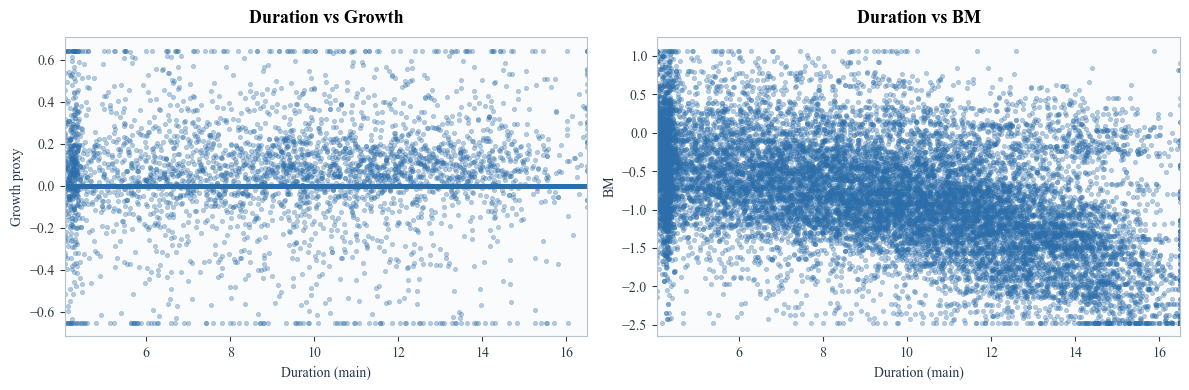

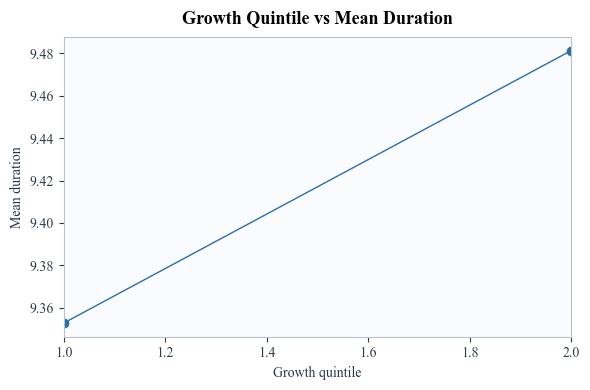

In [19]:
# Step 15C — requested plots (matplotlib only)
if 'val_growth_diag2' not in globals():
    raise RuntimeError('Run Step 15A and Step 15B first.')

plotdf = val_growth_diag2.copy()

bm_cmp = plotdf['bm_w'] if 'bm_w' in plotdf.columns else _winsor_series(plotdf['bm'], 0.01, 0.99)
growth_proxy = plotdf[validation_growth_proxy_used] if 'validation_growth_proxy_used' in globals() and validation_growth_proxy_used in plotdf.columns else plotdf['growth_ltg_w']

# 1) duration vs growth scatter
sc_g = pd.concat([plotdf['duration_main'], growth_proxy], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

# 2) duration vs bm scatter
sc_b = pd.concat([plotdf['duration_main'], bm_cmp], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(sc_g.iloc[:, 0], sc_g.iloc[:, 1], s=10, alpha=0.35)
ax[0].set_xlabel('Duration (main)')
ax[0].set_ylabel('Growth proxy')
ax[0].set_title('Duration vs Growth')

ax[1].scatter(sc_b.iloc[:, 0], sc_b.iloc[:, 1], s=10, alpha=0.35)
ax[1].set_xlabel('Duration (main)')
ax[1].set_ylabel('BM')
ax[1].set_title('Duration vs BM')

plt.tight_layout()
plt.show()

# 3) growth quintile vs mean duration
if growth_proxy.notna().sum() >= 5:
    qd = pd.DataFrame({'growth': growth_proxy, 'duration': plotdf['duration_main']}).dropna(subset=['growth']).copy()
    _q = pd.qcut(qd['growth'], q=5, duplicates='drop')
    qd['growth_quintile'] = (_q.cat.codes.replace(-1, np.nan) + 1).astype(float)
    line_tbl = qd.groupby('growth_quintile', dropna=False)['duration'].mean().reset_index().sort_values('growth_quintile')

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(line_tbl['growth_quintile'], line_tbl['duration'], marker='o')
    ax.set_xlabel('Growth quintile')
    ax.set_ylabel('Mean duration')
    ax.set_title('Growth Quintile vs Mean Duration')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient growth observations for quintile-duration plot.')




### Interpretation (Growth Sensitivity vs Stability)

- If `scale_factor` falls as growth rises, scaling likely compresses high-growth firms more strongly.
- If additional growth proxies increase `corr(duration, growth)` while `corr(duration, bm)` remains economically plausible, interpretability improves.
- If `duration_timing_only` loads more strongly on growth than price-anchored Macaulay, growth-timing information is present but partly dampened by valuation anchoring.
- The less-scaled variant (`floor = 0.90`) is a stability/sensitivity trade-off check: higher growth sensitivity can come with larger dispersion and potentially lower robustness.
